# Commute-Aware Rental Affordability Analyzer

A tool for a couple deciding where to live, built around one question most rental search sites can't answer: not just *"can I afford this rent,"* but *"is this responsible for my household, given my real commute, my real debts, and what happens if one of our incomes disappears."*

## What this notebook does

1. **Defines two people's work locations and required arrival times**, then computes real, traffic-aware commute isochrones (10/20/30/40/50/60-minute bands) using Mapbox's Directions and Isochrone APIs — actual driving time during rush hour, not straight-line distance.
2. **Pulls live, real rental listings** (via the RentCast API) inside that commute boundary — real addresses, real prices, real bedroom counts — instead of relying on aggregate government estimates.
3. **Filters those listings down to only the ones actually inside the real commute boundary**, using point-in-polygon geometry against the real isochrone shapes, not a simple radius circle.
4. **Runs a full financial model against every listing**: state and federal filing-status-aware tax, debts, recurring expenses, and real per-vehicle fuel costs (including a traffic/congestion cost model) — to determine, for every real listing, whether it's financially *feasible*, *responsible* under standard lending guidelines, and *safe* even in a worst-case scenario where one partner's income disappears.
5. **Separately models landlord screening odds** (the "3x rent" income rule) under three real-world lease-signing scenarios — either person signing alone, or both together — since who's on the lease determines both who a landlord checks and who's legally exposed if things go wrong.

## How to use it

Run the notebook top to bottom. Each `##` section under **Worksheet** is where you plug in real numbers (income, debts, vehicle, work locations). **Property Searcher** computes the real commute boundary; **Huds Dataset Alternative** pulls and filters real listings inside it; **Report Builder Engine** runs the financial math; **Report** is the final, formatted table.


---


# Packages, Datasets and API

Installs the geospatial/mapping stack (`geopandas`, `shapely`, `contextily`, `pygris`) plus `pgeocode` for zip-level lookups. Two API keys are required:

- **Mapbox** — powers the real traffic-aware commute isochrones and driving directions (free tier is generous; get one at [mapbox.com](https://www.mapbox.com)).
- **RentCast** — powers the live rental-listings pull (free tier: 50 requests/month; get one at [rentcast.io](https://www.rentcast.io/api)).

Replace the placeholder strings below with your own keys before running.


In [4]:
!pip install geopandas shapely requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 9.5 MB/s  0:00:02m 9.8 MB/s eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [geopandas]━ 1/2 [geopandas]


In [11]:
!pip install contextily matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 8.5 MB/s  0:00:028.3 MB/s eta 0:00:01:01
  Attempting uninstall: click
    Found existing installation: click 8.2.1
    Uninstalling click-8.2.1:
      Successfully uninstalled click-8.2.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [contextily] 6/7 [contextily]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
distributed 2025.11.0 requires dask==2025.11.0, but you have dask 2026.7.1 which is incompatible.
streamlit 1.51.0 requires packaging<26,>=20, but you have packaging 26.3 which is incompatible.


# Engine

Every reusable function and class the rest of the notebook depends on: the income-tax calculator, the commute-isochrone pipeline (and its visualizer), the debt and expense engines, and the vehicle/fuel-cost engine. Nothing here needs editing — run these cells once, then move to **Worksheet** to plug in your own numbers.


In [5]:
"""
General paycheck calculator: gross -> net pay for ANY US state.

No web scraping, no browser, no SmartAsset dependency — this replicates
the actual 2026 federal + state tax bracket math locally, sourced from
the Tax Foundation's 2026 State Individual Income Tax Rates and Brackets
(https://taxfoundation.org/data/all/state/state-income-tax-rates-2026/).

Structured in chunks so each piece can be edited independently:
  1. JOB INPUT    -> pay type, frequency, hours, state -> gross income
  2. TAX DATA     -> federal brackets + all-50-states + DC bracket tables
  3. TAX CALC     -> gross -> net, using the right state's brackets
  4. SUMMARY      -> report + optional chart

Caveats (same ones that apply to SmartAsset or any calculator like this):
  - Single filer only, standard deduction only (no itemizing, no credits
    beyond the standard/personal exemption baked into the bracket table).
  - Local/city income taxes (NYC, Yonkers, Philadelphia, etc.) are NOT
    included — footnote (a) in the source table lists which states have
    them; add manually if that applies to you.
  - A few states structure their "standard deduction" as a tax credit or
    personal exemption instead — those are approximated as an equivalent
    deduction here for simplicity, so treat results as close estimates,
    not exact withholding figures.

NOTE ON NAMING: uses person_1/person_2 (not person1/person2) throughout,
specifically so these variables don't collide with the Person objects
(person1/person2) used in the separate commute-bands project, if you're
running both in the same notebook session.
"""

from dataclasses import dataclass


# ══════════════════════════════════════════════════════════════════
# CHUNK 1: JOB INPUT — pay type, frequency, hours, state -> gross income
# ══════════════════════════════════════════════════════════════════

STATE_ABBREV = {
    "AL": "Alabama", "AK": "Alaska", "AZ": "Arizona", "AR": "Arkansas",
    "CA": "California", "CO": "Colorado", "CT": "Connecticut", "DE": "Delaware",
    "FL": "Florida", "GA": "Georgia", "HI": "Hawaii", "ID": "Idaho",
    "IL": "Illinois", "IN": "Indiana", "IA": "Iowa", "KS": "Kansas",
    "KY": "Kentucky", "LA": "Louisiana", "ME": "Maine", "MD": "Maryland",
    "MA": "Massachusetts", "MI": "Michigan", "MN": "Minnesota", "MS": "Mississippi",
    "MO": "Missouri", "MT": "Montana", "NE": "Nebraska", "NV": "Nevada",
    "NH": "New Hampshire", "NJ": "New Jersey", "NM": "New Mexico", "NY": "New York",
    "NC": "North Carolina", "ND": "North Dakota", "OH": "Ohio", "OK": "Oklahoma",
    "OR": "Oregon", "PA": "Pennsylvania", "RI": "Rhode Island", "SC": "South Carolina",
    "SD": "South Dakota", "TN": "Tennessee", "TX": "Texas", "UT": "Utah",
    "VT": "Vermont", "VA": "Virginia", "WA": "Washington", "WV": "West Virginia",
    "WI": "Wisconsin", "WY": "Wyoming", "DC": "Washington DC",
}


@dataclass
class Job:
    pay_type: str
    pay_frequency: str
    rate: float
    state: "str | list"
    hours_per_week: "float | None" = None
    weeks_per_year: float = 52.0
    filing_status: str = "single"
    spouse: "Earner | None" = None

    VALID_PAY_TYPES = {"hourly", "salary"}
    VALID_PAY_FREQUENCIES = {"weekly", "biweekly", "semimonthly", "monthly"}
    VALID_FILING_STATUSES = {"single", "married_filing_jointly"}

    def __post_init__(self):
        if self.pay_type not in self.VALID_PAY_TYPES:
            raise ValueError(
                f"pay_type must be one of {sorted(self.VALID_PAY_TYPES)}, got {self.pay_type!r}"
            )
        if self.pay_frequency not in self.VALID_PAY_FREQUENCIES:
            raise ValueError(
                f"pay_frequency must be one of {sorted(self.VALID_PAY_FREQUENCIES)}, "
                f"got {self.pay_frequency!r}"
            )
        if self.filing_status not in self.VALID_FILING_STATUSES:
            raise ValueError(
                f"filing_status must be one of {sorted(self.VALID_FILING_STATUSES)}, "
                f"got {self.filing_status!r}"
            )
        if self.filing_status == "married_filing_jointly" and self.spouse is None:
            raise ValueError(
                "filing_status='married_filing_jointly' requires spouse=Earner(...) to be set"
            )
        if self.pay_type == "hourly" and self.hours_per_week is None:
            raise ValueError(
                "hours_per_week is required when pay_type='hourly' (e.g. hours_per_week=40)"
            )
        if self.pay_type == "salary":
            self.hours_per_week = 0
        self.states_list()

    def is_married(self) -> bool:
        return self.filing_status == "married_filing_jointly"

    def is_multi_state(self) -> bool:
        return isinstance(self.state, list)

    def states_list(self) -> list:
        raw = self.state if self.is_multi_state() else [self.state]
        return [self._normalize_one(s) for s in raw]

    def _normalize_one(self, s: str) -> str:
        s = s.strip()
        if s.upper() in STATE_ABBREV:
            return STATE_ABBREV[s.upper()]
        for full_name in STATE_ABBREV.values():
            if s.lower() == full_name.lower():
                return full_name
        raise ValueError(f"Unrecognized state: {s!r}")

    def gross_annual(self) -> float:
        if self.pay_type == "hourly":
            return self.rate * self.hours_per_week * self.weeks_per_year
        elif self.pay_type == "salary":
            return self.rate
        raise ValueError("pay_type must be 'hourly' or 'salary'")

    def periods_per_year(self) -> int:
        return {"weekly": 52, "biweekly": 26, "semimonthly": 24, "monthly": 12}[self.pay_frequency]

    def gross_per_period(self) -> float:
        return self.gross_annual() / self.periods_per_year()


# ══════════════════════════════════════════════════════════════════
# CHUNK 2: TAX DATA — federal + all state bracket tables (2026, single filer)
# ══════════════════════════════════════════════════════════════════

FEDERAL_STANDARD_DEDUCTION = 16100

FEDERAL_BRACKETS = [
    (0,       11925,  0.10),
    (11925,   48475,  0.12),
    (48475,   103350, 0.22),
    (103350,  197300, 0.24),
    (197300,  250525, 0.32),
    (250525,  626350, 0.35),
    (626350,  float("inf"), 0.37),
]

STATE_TAX_DATA = {
    "Alabama":        (3000,  [(0, 0.02), (500, 0.04), (3000, 0.05)]),
    "Alaska":         (0,     []),
    "Arizona":        (8350,  [(0, 0.025)]),
    "Arkansas":       (2470,  [(0, 0.02), (4600, 0.039)]),
    "California":     (5540,  [(0, 0.01), (11079, 0.02), (26264, 0.04), (41452, 0.06),
                                (57542, 0.08), (72724, 0.093), (371479, 0.103),
                                (445771, 0.113), (742953, 0.123), (1000000, 0.133)]),
    "Colorado":       (16100, [(0, 0.044)]),
    "Connecticut":    (0,     [(0, 0.02), (10000, 0.045), (50000, 0.055), (100000, 0.06),
                                (200000, 0.065), (250000, 0.069), (500000, 0.0699)]),
    "Delaware":       (3250,  [(0, 0.022), (5000, 0.039), (10000, 0.048), (20000, 0.052),
                                (25000, 0.0555), (60000, 0.066)]),
    "Florida":        (0,     []),
    "Georgia":        (12000, [(0, 0.0519)]),
    "Hawaii":         (4400,  [(0, 0.014), (9600, 0.032), (14400, 0.055), (19200, 0.064),
                                (24000, 0.068), (36000, 0.072), (48000, 0.076),
                                (125000, 0.079), (175000, 0.0825), (225000, 0.09),
                                (275000, 0.10), (325000, 0.11)]),
    "Idaho":          (16100, [(0, 0.0), (4811, 0.053)]),
    "Illinois":       (2925,  [(0, 0.0495)]),
    "Indiana":        (1000,  [(0, 0.0295)]),
    "Iowa":           (16100, [(0, 0.038)]),
    "Kansas":         (3605,  [(0, 0.052), (23000, 0.0558)]),
    "Kentucky":       (3360,  [(0, 0.035)]),
    "Louisiana":      (12875, [(0, 0.03)]),
    "Maine":          (8350,  [(0, 0.058), (27399, 0.0675), (64849, 0.0715)]),
    "Maryland":       (3350,  [(0, 0.02), (1000, 0.03), (2000, 0.04), (3000, 0.0475),
                                (100000, 0.05), (125000, 0.0525), (150000, 0.055),
                                (250000, 0.0575), (500000, 0.0625), (1000000, 0.065)]),
    "Massachusetts":  (4400,  [(0, 0.05), (1083150, 0.09)]),
    "Michigan":       (5900,  [(0, 0.0425)]),
    "Minnesota":      (15300, [(0, 0.0535), (33310, 0.068), (109430, 0.0785), (203150, 0.0985)]),
    "Mississippi":    (2300,  [(0, 0.0), (10000, 0.04)]),
    "Missouri":       (16100, [(0, 0.0), (1348, 0.02), (2696, 0.025), (4044, 0.03),
                                (5392, 0.035), (6740, 0.04), (8088, 0.045), (9436, 0.047)]),
    "Montana":        (16100, [(0, 0.047), (47500, 0.0565)]),
    "Nebraska":       (8850,  [(0, 0.0246), (4130, 0.0351), (24760, 0.0455)]),
    "Nevada":         (0,     []),
    "New Hampshire":  (0,     []),
    "New Jersey":     (1000,  [(0, 0.014), (20000, 0.0175), (35000, 0.035),
                                (40000, 0.0553), (75000, 0.0637), (500000, 0.0897),
                                (1000000, 0.1075)]),
    "New Mexico":     (16100, [(0, 0.015), (5500, 0.032), (16500, 0.043),
                                (33500, 0.047), (66500, 0.049), (210000, 0.059)]),
    "New York":       (8000,  [(0, 0.039), (8500, 0.044), (11700, 0.0515), (13900, 0.054),
                                (80650, 0.059), (215400, 0.0685), (1077550, 0.0965),
                                (5000000, 0.103), (25000000, 0.109)]),
    "North Carolina": (12750, [(0, 0.0399)]),
    "North Dakota":   (16100, [(0, 0.0), (48475, 0.0195), (244825, 0.025)]),
    "Ohio":           (2400,  [(0, 0.0), (26050, 0.0275)]),
    "Oklahoma":       (6350,  [(0, 0.0), (3750, 0.025), (4900, 0.035), (7200, 0.045)]),
    "Oregon":         (2910,  [(0, 0.0475), (4550, 0.0675), (11400, 0.0875), (125000, 0.099)]),
    "Pennsylvania":   (0,     [(0, 0.0307)]),
    "Rhode Island":   (11200, [(0, 0.0375), (82050, 0.0475), (186450, 0.0599)]),
    "South Carolina": (8350,  [(0, 0.0), (3640, 0.03), (18230, 0.06)]),
    "South Dakota":   (0,     []),
    "Tennessee":      (0,     []),
    "Texas":          (0,     []),
    "Utah":           (0,     [(0, 0.045)]),
    "Vermont":        (7650,  [(0, 0.0335), (49400, 0.066), (119700, 0.076), (249700, 0.0875)]),
    "Virginia":       (8750,  [(0, 0.02), (3000, 0.03), (5000, 0.05), (17000, 0.0575)]),
    "Washington":     (0,     []),
    "West Virginia":  (2000,  [(0, 0.0222), (10000, 0.0296), (25000, 0.0333),
                                (40000, 0.0444), (60000, 0.0482)]),
    "Wisconsin":      (13960, [(0, 0.035), (15110, 0.044), (51950, 0.053), (332720, 0.0765)]),
    "Wyoming":        (0,     []),
    "Washington DC":  (16100, [(0, 0.04), (10000, 0.06), (40000, 0.065),
                                (60000, 0.085), (250000, 0.0925), (500000, 0.0975),
                                (1000000, 0.1075)]),
}


# ══════════════════════════════════════════════════════════════════
# CHUNK 3: TAX CALC — gross -> net using the right bracket tables
# ══════════════════════════════════════════════════════════════════

def _apply_brackets(taxable_income: float, brackets: list) -> float:
    if not brackets or taxable_income <= 0:
        return 0.0
    tax = 0.0
    for i, (lower, rate) in enumerate(brackets):
        upper = brackets[i + 1][0] if i + 1 < len(brackets) else float("inf")
        if taxable_income > lower:
            tax += (min(taxable_income, upper) - lower) * rate
        else:
            break
    return tax


def federal_tax(taxable_income: float) -> float:
    return _apply_brackets(taxable_income, [(l, r) for l, u, r in FEDERAL_BRACKETS])


def state_tax(taxable_income: float, state_name: str) -> float:
    _, brackets = STATE_TAX_DATA[state_name]
    return _apply_brackets(taxable_income, brackets)


def fica_tax(gross_income: float) -> float:
    ss_wage_base_2026 = 176100
    social_security = min(gross_income, ss_wage_base_2026) * 0.062
    medicare = gross_income * 0.0145
    return social_security + medicare


def compute_net_income(job: "Job", state_name: str) -> dict:
    state_std_deduction, _ = STATE_TAX_DATA[state_name]

    gross_annual = job.gross_annual()
    fed_taxable = max(0, gross_annual - FEDERAL_STANDARD_DEDUCTION)
    state_taxable = max(0, gross_annual - state_std_deduction)

    fed = federal_tax(fed_taxable)
    st = state_tax(state_taxable, state_name)
    fica = fica_tax(gross_annual)
    total_tax = fed + st + fica

    return {
        "state": state_name,
        "gross_annual": gross_annual,
        "federal_tax": fed,
        "state_tax": st,
        "fica": fica,
        "total_tax": total_tax,
        "net_annual": gross_annual - total_tax,
        "net_monthly": (gross_annual - total_tax) / 12,
        "net_per_period": (gross_annual - total_tax) / job.periods_per_year(),
    }


def compute_all(job: "Job") -> list:
    return [compute_net_income(job, state) for state in job.states_list()]


# ══════════════════════════════════════════════════════════════════
# CHUNK 4: SUMMARY — report (and optional chart)
# ══════════════════════════════════════════════════════════════════

def _print_single_report(job: "Job", r: dict) -> None:
    print("=" * 55)
    print(f"JOB: {job.pay_type} @ {job.rate}, {r['state']}, paid {job.pay_frequency}")
    print(f"Gross per pay period: ${job.gross_per_period():,.2f} "
          f"({job.periods_per_year()} periods/yr)")
    print(f"GROSS INCOME: ${r['gross_annual']:,.2f}/yr "
          f"(${r['gross_annual']/12:,.2f}/mo)")
    print("-" * 55)
    print(f"Federal tax:  ${r['federal_tax']:,.2f}")
    print(f"State tax:    ${r['state_tax']:,.2f}")
    print(f"FICA:         ${r['fica']:,.2f}")
    print(f"Total tax:    ${r['total_tax']:,.2f} "
          f"({r['total_tax']/r['gross_annual']:.1%} effective rate)")
    print("-" * 55)
    print(f"NET INCOME: ${r['net_annual']:,.2f}/yr "
          f"(${r['net_monthly']:,.2f}/mo, ${r['net_per_period']:,.2f}/{job.pay_frequency} period)")
    print("=" * 55)


def _print_comparison_table(job: "Job", results: list) -> None:
    print("=" * 74)
    print(f"JOB: {job.pay_type} @ {job.rate}, paid {job.pay_frequency} "
          f"— comparing {len(results)} states")
    print("-" * 74)
    period_label = f"Net/{job.pay_frequency}"
    print(f"{'State':<18} {'Net/yr':>12} {'Net/mo':>12} {period_label:>14} {'Effective rate':>15}")
    print("-" * 74)
    for r in sorted(results, key=lambda r: -r["net_annual"]):
        print(f"{r['state']:<18} ${r['net_annual']:>10,.0f} ${r['net_monthly']:>10,.0f} "
              f"${r['net_per_period']:>12,.0f} {r['total_tax']/r['gross_annual']:>14.1%}")
    print("=" * 74)


def run_analysis(job: "Job") -> None:
    if job.is_married():
        household = Household(
            person_1=Earner(job.pay_type, job.pay_frequency, job.rate,
                             job.hours_per_week, job.weeks_per_year),
            spouse=job.spouse,
            state=job.state,
        )
        run_household_analysis(household)
        return

    results = compute_all(job)
    if job.is_multi_state():
        _print_comparison_table(job, results)
    else:
        _print_single_report(job, results[0])


# ══════════════════════════════════════════════════════════════════
# CHUNK 5: MARRIED FILING JOINTLY — combine two incomes into one household
# ══════════════════════════════════════════════════════════════════

FEDERAL_STANDARD_DEDUCTION_MFJ = 32200

FEDERAL_BRACKETS_MFJ = [
    (0,       23850,   0.10),
    (23850,   96950,   0.12),
    (96950,   206700,  0.22),
    (206700,  394600,  0.24),
    (394600,  501050,  0.32),
    (501050,  751600,  0.35),
    (751600,  float("inf"), 0.37),
]

FEDERAL_STANDARD_DEDUCTION_MFS = 16100

FEDERAL_BRACKETS_MFS = [
    (0,       11925,   0.10),
    (11925,   48475,   0.12),
    (48475,   103350,  0.22),
    (103350,  197300,  0.24),
    (197300,  250525,  0.32),
    (250525,  375800,  0.35),
    (375800,  float("inf"), 0.37),
]


@dataclass
class Earner:
    pay_type: str
    pay_frequency: str
    rate: float
    hours_per_week: "float | None" = None
    weeks_per_year: float = 52.0

    def __post_init__(self):
        if self.pay_type not in Job.VALID_PAY_TYPES:
            raise ValueError(f"pay_type must be one of {sorted(Job.VALID_PAY_TYPES)}, got {self.pay_type!r}")
        if self.pay_frequency not in Job.VALID_PAY_FREQUENCIES:
            raise ValueError(f"pay_frequency must be one of {sorted(Job.VALID_PAY_FREQUENCIES)}, got {self.pay_frequency!r}")
        if self.pay_type == "hourly" and self.hours_per_week is None:
            raise ValueError("hours_per_week is required when pay_type='hourly' (e.g. hours_per_week=40)")
        if self.pay_type == "salary":
            self.hours_per_week = 0

    def gross_annual(self) -> float:
        if self.pay_type == "hourly":
            return self.rate * self.hours_per_week * self.weeks_per_year
        return self.rate

    def periods_per_year(self) -> int:
        return {"weekly": 52, "biweekly": 26, "semimonthly": 24, "monthly": 12}[self.pay_frequency]

    def gross_per_period(self) -> float:
        return self.gross_annual() / self.periods_per_year()


@dataclass
class Household:
    person_1: "Earner"
    state: "str | list"
    spouse: "Earner | None" = None

    def states_list(self) -> list:
        raw = self.state if isinstance(self.state, list) else [self.state]
        return [Job._normalize_one(self, s) for s in raw]

    def is_multi_state(self) -> bool:
        return isinstance(self.state, list)


def _state_mfj_std_deduction_and_brackets(state_name: str):
    single_std, single_brackets = STATE_TAX_DATA[state_name]
    mfj_std = single_std * 2
    mfj_brackets = [(lower * 2, rate) for lower, rate in single_brackets]
    return mfj_std, mfj_brackets


def compute_household(household: "Household", state_name: str, file_separately: bool = False) -> dict:
    gross1 = household.person_1.gross_annual()
    gross2 = household.spouse.gross_annual()
    combined_gross = gross1 + gross2

    if file_separately:
        fed1_taxable = max(0, gross1 - FEDERAL_STANDARD_DEDUCTION_MFS)
        fed2_taxable = max(0, gross2 - FEDERAL_STANDARD_DEDUCTION_MFS)
        fed = (_apply_brackets(fed1_taxable, [(l, r) for l, u, r in FEDERAL_BRACKETS_MFS]) +
               _apply_brackets(fed2_taxable, [(l, r) for l, u, r in FEDERAL_BRACKETS_MFS]))
        single_std, single_brackets = STATE_TAX_DATA[state_name]
        st = (_apply_brackets(max(0, gross1 - single_std), single_brackets) +
              _apply_brackets(max(0, gross2 - single_std), single_brackets))
    else:
        fed_taxable = max(0, combined_gross - FEDERAL_STANDARD_DEDUCTION_MFJ)
        fed = _apply_brackets(fed_taxable, [(l, r) for l, u, r in FEDERAL_BRACKETS_MFJ])

        mfj_std, mfj_brackets = _state_mfj_std_deduction_and_brackets(state_name)
        state_taxable = max(0, combined_gross - mfj_std)
        st = _apply_brackets(state_taxable, mfj_brackets)

    fica1 = fica_tax(gross1)
    fica2 = fica_tax(gross2)
    fica_total = fica1 + fica2

    total_tax = fed + st + fica_total
    net_household_annual = combined_gross - total_tax

    share1 = gross1 / combined_gross if combined_gross else 0
    share2 = 1 - share1

    return {
        "state": state_name,
        "gross1": gross1, "gross2": gross2, "combined_gross": combined_gross,
        "federal_tax": fed, "state_tax": st, "fica_total": fica_total, "total_tax": total_tax,
        "net_household_annual": net_household_annual,
        "net_household_monthly": net_household_annual / 12,
        "net1_annual": net_household_annual * share1,
        "net2_annual": net_household_annual * share2,
    }


def _print_household_table(household: "Household", results: list, file_separately: bool = False) -> None:
    label = "married filing separately" if file_separately else "married filing jointly"
    for r in results:
        print("=" * 74)
        print(f"STATE: {r['state']}  ({label})")
        print("-" * 74)
        print(f"{'':<12} {'Gross/yr':>12} {'Net/yr':>12} {'Net/mo':>10}")
        print(f"{'Person 1':<12} ${r['gross1']:>10,.0f} ${r['net1_annual']:>10,.0f} "
              f"${r['net1_annual']/12:>8,.0f}")
        print(f"{'Spouse':<12} ${r['gross2']:>10,.0f} ${r['net2_annual']:>10,.0f} "
              f"${r['net2_annual']/12:>8,.0f}")
        print("-" * 74)
        print(f"{'Combined':<12} ${r['combined_gross']:>10,.0f} ${r['net_household_annual']:>10,.0f} "
              f"${r['net_household_monthly']:>8,.0f}  "
              f"({r['total_tax']/r['combined_gross']:.1%} effective rate)")
    print("=" * 74)


def analyze(person_1: "Earner", state: "str | list", person_2: "Earner | None" = None,
            include_person_2: bool = True, married: bool = False,
            file_separately: bool = False, state2: "str | None" = None) -> "dict | None":
    """
    One entry point for every case:
      - include_person_2=False (or person_2=None)         -> person_1 alone, single filer
      - person_2=Earner(...), married=False                -> two unmarried people, each
                                                              taxed independently, summed
      - person_2=Earner(...), married=True, file_separately=False -> married filing jointly
      - person_2=Earner(...), married=True, file_separately=True  -> married filing separately

    include_person_2: set this to False to run the solo analysis WITHOUT
    deleting or commenting out your `person_2 = Earner(...)` line — handy
    if you want to keep that line ready to flip back on later. Leaving
    person_2=None entirely does the same thing; this flag is just a
    cleaner on/off switch when the line is already there.

    file_separately only matters when married=True — married couples can
    legally choose either filing status each year, it isn't automatic.
    It has no effect when married=False.

    state2: set this ONLY if the two people are taxed in DIFFERENT states
    (e.g. a remote couple domiciled in different places). When set, `state`
    must be a single state (not a list) for person_1, and state2 is
    person_2's state. Federal tax always combines correctly regardless of
    state2, since federal doesn't care about state residency. State tax
    when state2 is set is computed independently per person in their own
    state — see the printed caveat, this is an approximation for the
    married+different-states case specifically.
    """
    if not include_person_2:
        person_2 = None

    if state2 is not None:
        if person_2 is None:
            raise ValueError("state2 requires person_2 to be set — it only makes sense for two people.")
        if isinstance(state, list):
            raise ValueError("When using state2, `state` must be a single state (not a list) for person_1.")
        return _analyze_two_states(person_1, person_2, state, state2, married, file_separately)

    states = Household(person_1=person_1, state=state).states_list()

    if person_2 is None:
        results = [compute_net_income(person_1, s) for s in states]
        if len(states) > 1:
            _print_comparison_table(person_1, results)
        else:
            _print_single_report(person_1, results[0])
        return

    if married:
        household = Household(person_1=person_1, spouse=person_2, state=state)
        results = [compute_household(household, s, file_separately) for s in states]
        _print_household_table(household, results, file_separately)
        return

    for s in states:
        r1 = compute_net_income(person_1, s)
        r2 = compute_net_income(person_2, s)
        combined_net_annual = r1["net_annual"] + r2["net_annual"]
        combined_gross = r1["gross_annual"] + r2["gross_annual"]

        print("=" * 74)
        print(f"STATE: {s}  (two unmarried people, each filing single)")
        print("-" * 74)
        print(f"{'':<12} {'Gross/yr':>12} {'Net/yr':>12} {'Net/mo':>10}")
        print(f"{'Person 1':<12} ${r1['gross_annual']:>10,.0f} ${r1['net_annual']:>10,.0f} "
              f"${r1['net_monthly']:>8,.0f}")
        print(f"{'Person 2':<12} ${r2['gross_annual']:>10,.0f} ${r2['net_annual']:>10,.0f} "
              f"${r2['net_monthly']:>8,.0f}")
        print("-" * 74)
        print(f"{'Combined':<12} ${combined_gross:>10,.0f} ${combined_net_annual:>10,.0f} "
              f"${combined_net_annual/12:>8,.0f}  "
              f"({(r1['total_tax']+r2['total_tax'])/combined_gross:.1%} effective rate)")
    print("=" * 74)


def _analyze_two_states(person_1: "Earner", person_2: "Earner", state1: str, state2: str,
                         married: bool, file_separately: bool = False) -> dict:
    s1 = Job._normalize_one(None, state1)
    s2 = Job._normalize_one(None, state2)

    gross1 = person_1.gross_annual()
    gross2 = person_2.gross_annual()
    combined_gross = gross1 + gross2
    fica1 = fica_tax(gross1)
    fica2 = fica_tax(gross2)

    if married and not file_separately:
        fed_taxable = max(0, combined_gross - FEDERAL_STANDARD_DEDUCTION_MFJ)
        fed_joint = _apply_brackets(fed_taxable, [(l, r) for l, u, r in FEDERAL_BRACKETS_MFJ])
        share1 = gross1 / combined_gross if combined_gross else 0
        fed1 = fed_joint * share1
        fed2 = fed_joint - fed1
        fed = fed_joint
        caveat = ("NOTE: married filing jointly across two different states is genuinely\n"
                  "complex — most states don't cleanly support 'joint federal, spouse lives\n"
                  "elsewhere.' State tax below is APPROXIMATED by taxing each spouse's own\n"
                  "income independently, single-filer style, in their own state. The Federal\n"
                  "column per person below is ALSO approximated — split by each person's share\n"
                  "of combined gross income, since MFJ federal tax is filed as one joint number,\n"
                  "not two individual ones. Verify the actual rules for this specific state pair\n"
                  "(reciprocity agreements, credit for taxes paid to another state, etc.) before\n"
                  "relying on this.")
    elif married and file_separately:
        fed1_taxable = max(0, gross1 - FEDERAL_STANDARD_DEDUCTION_MFS)
        fed2_taxable = max(0, gross2 - FEDERAL_STANDARD_DEDUCTION_MFS)
        fed1 = _apply_brackets(fed1_taxable, [(l, r) for l, u, r in FEDERAL_BRACKETS_MFS])
        fed2 = _apply_brackets(fed2_taxable, [(l, r) for l, u, r in FEDERAL_BRACKETS_MFS])
        fed = fed1 + fed2
        caveat = ("NOTE: married filing separately with each spouse in a different state is\n"
                  "close to how this actually plays out in practice — each spouse's federal\n"
                  "MFS tax and each state's own tax are already computed independently below.")
    else:
        fed1_taxable = max(0, gross1 - FEDERAL_STANDARD_DEDUCTION)
        fed2_taxable = max(0, gross2 - FEDERAL_STANDARD_DEDUCTION)
        fed1 = federal_tax(fed1_taxable)
        fed2 = federal_tax(fed2_taxable)
        fed = fed1 + fed2
        caveat = None

    std1, brackets1 = STATE_TAX_DATA[s1]
    std2, brackets2 = STATE_TAX_DATA[s2]
    st1 = _apply_brackets(max(0, gross1 - std1), brackets1)
    st2 = _apply_brackets(max(0, gross2 - std2), brackets2)
    state_total = st1 + st2

    total_tax1 = fed1 + st1 + fica1
    total_tax2 = fed2 + st2 + fica2
    net1 = gross1 - total_tax1
    net2 = gross2 - total_tax2

    total_tax = fed + state_total + fica1 + fica2
    net_annual = combined_gross - total_tax

    if married:
        label = "married filing separately" if file_separately else "married filing jointly"
    else:
        label = "two unmarried people, each filing single"
    print("=" * 96)
    print(f"Person 1 taxed in {s1}, Person 2 taxed in {s2}  ({label})")
    if caveat:
        print("-" * 96)
        print(caveat)
    print("-" * 96)
    print(f"{'':<12} {'State':<16} {'Gross/yr':>12} {'Federal':>11} {'State tax':>11} "
          f"{'FICA':>9} {'Total tax':>11} {'After Tax':>11}")
    print(f"{'Person 1':<12} {s1:<16} ${gross1:>10,.0f} ${fed1:>9,.0f} ${st1:>9,.0f} "
          f"${fica1:>7,.0f} ${total_tax1:>9,.0f} ${net1:>9,.0f}")
    print(f"{'Person 2':<12} {s2:<16} ${gross2:>10,.0f} ${fed2:>9,.0f} ${st2:>9,.0f} "
          f"${fica2:>7,.0f} ${total_tax2:>9,.0f} ${net2:>9,.0f}")
    print("-" * 96)
    print(f"Combined gross:     ${combined_gross:,.0f}/yr")
    print(f"Federal tax:        ${fed:,.0f}")
    print(f"State tax (summed): ${state_total:,.0f}")
    print(f"FICA:               ${fica1+fica2:,.0f}")
    print(f"Total tax:          ${total_tax:,.0f} ({total_tax/combined_gross:.1%} effective rate)")
    print("-" * 96)
    print(f"NET INCOME: ${net_annual:,.0f}/yr (${net_annual/12:,.0f}/mo)")
    print("=" * 96)

    return {
        "label": label,
        "gross1": gross1,
        "gross2": gross2,
        "combined_gross": combined_gross,
        "net1": net1,
        "net2": net2,
        "net_annual": net_annual,
    }


if __name__ == "__main__":
    print("This file is the calculator engine — no job is defined here.\n"
          "See my_job_analysis.py for an example that imports it and\n"
          "defines its own Job(...) variables.")

This file is the calculator engine — no job is defined here.
See my_job_analysis.py for an example that imports it and
defines its own Job(...) variables.


In [6]:
"""
Commute-band pipeline: for a given office location and required arrival
time, compute 9 real-world commute bands (10/20/.../90 min DURING RUSH
HOUR), correctly adjusted for congestion, classify candidate ZIP codes
into those bands via real spatial overlay (not point-sampling), and
join against HUD rent data.

PIPELINE ORDER (this matters — see the free-flow speed discussion):
  1. Real-world target bands (10,20,...,90 min) ÷ congestion multiplier
     for the required arrival hour = adjusted (smaller) time budgets
  2. Adjusted time budgets -> openrouteservice isochrone requests ->
     CUMULATIVE polygons (ORS's isochrone endpoint returns "everything
     reachable within X minutes", which naturally includes everything
     reachable in less time too)
  3. Subtract consecutive cumulative polygons -> RING-only polygons
     (e.g. the "20-40 min ring" = the 40-min shape minus the 20-min shape)
  4. Spatial overlay: which ZCTA boundaries intersect which ring, and
     by how much (% of the ZIP's area actually inside that ring)
  5. Join the resulting ZIP list against HUD rent data

Requires: pip install geopandas shapely requests
"""

from dataclasses import dataclass
import geopandas as gpd
from shapely.geometry import shape, Polygon
import requests
import time

MAPBOX_DIRECTIONS_URL = "https://api.mapbox.com/directions/v5/mapbox/driving-traffic/{coords}"


# ══════════════════════════════════════════════════════════════════
# COUPLE SUPPORT: two people, each either in-office (with coordinates)
# or remote (no commute constraint at all)
# ══════════════════════════════════════════════════════════════════

@dataclass
class Person:
    name: str
    include: bool = True                        # flip True/False without deleting this block — same pattern as PropertySlot/DebtSlot
    works_remote: bool = False
    required_arrival_iso: "str | None" = None    # this person's own required arrival time — e.g. "2026-09-01T07:45"
                                                   # required if works_remote=False and include=True; ignored otherwise
    anchor_lat: "float | None" = None             # if works_remote=False: their WORK DESTINATION (drives commute-band math)
                                                   # if works_remote=True: OPTIONAL — just a point of interest
                                                   # (e.g. a coworking space, a gym, family) — NEVER drives any
                                                   # commute-band computation, purely informational/for future use
    anchor_lon: "float | None" = None
    commute_days_per_week: int = 5                # how many days/week this person actually commutes to anchor_lat/lon —
                                                   # 1-7, so commute cost reflects THEIR real schedule instead of a
                                                   # generalized 5-day assumption. Ignored if works_remote=True.

    def __post_init__(self):
        if not self.include:
            return   # excluded from the analysis entirely — nothing else needs to be valid
        if not self.works_remote:
            if self.anchor_lat is None or self.anchor_lon is None:
                raise ValueError(f"{self.name}: anchor_lat/anchor_lon (work destination) required "
                                  f"when works_remote=False and include=True")
            if self.required_arrival_iso is None:
                raise ValueError(f"{self.name}: required_arrival_iso required when works_remote=False and include=True")
            if not (1 <= self.commute_days_per_week <= 7):
                raise ValueError(f"{self.name}: commute_days_per_week must be between 1 and 7, "
                                  f"got {self.commute_days_per_week}")


def get_office_to_office_drive_time(person1: Person, person2: Person, mapbox_token: str) -> float:
    """One cheap Directions API call — NOT a full isochrone — just the
    direct drive time in minutes between the two people's work
    destinations. Used for the feasibility pre-check, so we don't waste
    isochrone requests on bands that can't possibly overlap."""
    coords = f"{person1.anchor_lon},{person1.anchor_lat};{person2.anchor_lon},{person2.anchor_lat}"
    url = MAPBOX_DIRECTIONS_URL.format(coords=coords)
    response = requests.get(url, params={"access_token": mapbox_token}, timeout=30)
    print(f"[mapbox directions] status={response.status_code} (office-to-office check)")
    if response.status_code != 200:
        print("Response:", response.text[:500])
        response.raise_for_status()
    data = response.json()
    duration_minutes = data["routes"][0]["duration"] / 60
    return duration_minutes


def check_band_feasibility(office_to_office_minutes: float, bands: list) -> dict:
    """
    Heuristic pre-check, not a geometric guarantee: two X-minute
    reachable areas around two points can only overlap at all if
    2*X >= the direct drive time between those two points (best case —
    someone living exactly on the route, splitting the drive evenly).
    Real road networks aren't perfectly symmetric, so treat this as a
    reasonable early filter, not a precise cutoff.

    Returns {band: True/False}.
    """
    return {band: (2 * band) >= office_to_office_minutes for band in bands}


def print_feasibility_report(office_to_office_minutes: float, feasibility: dict) -> None:
    print("=" * 74)
    print(f"Office-to-office drive time: {office_to_office_minutes:.1f} minutes")
    print("-" * 74)
    for band, feasible in feasibility.items():
        status = "feasible — will search" if feasible else "INFEASIBLE — skipped (offices too far apart for this band)"
        print(f"  {band}-min band: {status}")
    print("=" * 74)


def intersect_two_offices(rings1: dict, rings2: dict) -> dict:
    """
    For a couple who BOTH work in-office (possibly different locations):
    the correct combination is INTERSECTION, not union — you want areas
    close to BOTH offices, not either one. Only bands present in both
    dicts are computed (bands skipped by the feasibility check won't be
    in here at all).
    """
    result = {}
    for band in rings1:
        if band not in rings2:
            continue
        intersection = rings1[band].intersection(rings2[band])
        if intersection.is_empty:
            print(f"  {band}-min band: geometrically feasible per the pre-check, but the actual "
                  f"isochrones don't overlap — no real candidate ZIPs for this band.")
            continue
        result[band] = intersection
    return result


def _get_isochrones_all_bands(office_lat: float, office_lon: float, required_arrival_iso: str,
                                mapbox_token: str, ors_api_key: "str | None", bands: list) -> dict:
    """Splits bands automatically: <=60min via Mapbox (real traffic-aware),
    >60min via ORS fallback (free-flow only, no traffic data available at
    that range). Merges both into one combined {band: polygon} dict."""
    mapbox_bands = [b for b in bands if b <= 60]
    fallback_bands = [b for b in bands if b > 60]

    result = {}
    if mapbox_bands:
        result.update(get_mapbox_isochrones_arrive_by(
            office_lat, office_lon, required_arrival_iso, mapbox_token, mapbox_bands
        ))
    if fallback_bands:
        if ors_api_key is None:
            print(f"WARNING: bands {fallback_bands} need the ORS fallback (>60 min), "
                  f"but no ors_api_key was provided — skipping these bands entirely.")
        else:
            result.update(get_ors_fallback_isochrones(office_lat, office_lon, fallback_bands, ors_api_key))
    return result


def get_couple_commute_bands(person1: Person, person2: Person,
                               mapbox_token: str, ors_api_key: "str | None" = None,
                               bands: list = None) -> dict:
    """
    One entry point for every case — driven entirely by fields already
    set on person1/person2, nothing else to pass in:
      - person2.include=False           -> person1 alone (solo case)
      - person2.works_remote=True       -> collapses to person1 alone
                                            (remote worker has no commute constraint,
                                            their anchor_lat/lon is just a point of
                                            interest, never used here)
      - both in-office (include=True, works_remote=False for both) ->
                                            feasibility pre-check, then INTERSECTION
                                            of both people's rings — each using their
                                            OWN required_arrival_iso, since a couple
                                            can have different start times

    ors_api_key: required if any requested band is above 60 minutes —
    Mapbox's isochrone API has a hard 60-minute cap, so anything beyond
    that automatically falls back to ORS (free-flow only, no traffic
    adjustment available at that range — a real accuracy gap, not a
    shortcut, since Mapbox structurally can't do traffic-aware data
    past 60 minutes at all).
    """
    if bands is None:
        bands = MAPBOX_BANDS

    if not person2.include or person2.works_remote:
        print("Single-office search (solo, or partner works remote — no commute constraint from them).")
        return _get_isochrones_all_bands(
            person1.anchor_lat, person1.anchor_lon, person1.required_arrival_iso,
            mapbox_token, ors_api_key, bands
        )

    # both work in-office — feasibility check first
    office_to_office = get_office_to_office_drive_time(person1, person2, mapbox_token)
    feasibility = check_band_feasibility(office_to_office, bands)
    print_feasibility_report(office_to_office, feasibility)

    feasible_bands = [b for b, ok in feasibility.items() if ok]
    if not feasible_bands:
        print("No bands are feasible — the two offices are too far apart for any of the requested bands.")
        return {}

    rings1 = _get_isochrones_all_bands(
        person1.anchor_lat, person1.anchor_lon, person1.required_arrival_iso,
        mapbox_token, ors_api_key, feasible_bands
    )
    rings2 = _get_isochrones_all_bands(
        person2.anchor_lat, person2.anchor_lon, person2.required_arrival_iso,
        mapbox_token, ors_api_key, feasible_bands
    )
    return intersect_two_offices(rings1, rings2)


MAPBOX_BANDS = [10, 20, 30, 40, 50, 60]   # Mapbox handles these, WITH real traffic adjustment
FALLBACK_BANDS = [70, 80, 90]              # beyond Mapbox's 60-min hard cap — no traffic data, less precise
TARGET_BANDS_MINUTES = MAPBOX_BANDS + FALLBACK_BANDS


# ══════════════════════════════════════════════════════════════════
# STEP 1 (Mapbox path): real traffic-aware isochrones, no manual math
# ══════════════════════════════════════════════════════════════════
#
# Mapbox's Isochrone API supports profile="driving-traffic" + depart_at,
# which reflects REAL historical traffic patterns for that specific time
# — this replaces the whole TomTom-multiplier workaround entirely for
# any band <= 60 minutes. Hard limits from Mapbox's own docs: max 60
# minutes per contour, max 4 contours per request (so 6 bands = 2 calls).

MAPBOX_ISOCHRONE_URL = "https://api.mapbox.com/isochrone/v1/mapbox/driving-traffic/{lon},{lat}"


def get_mapbox_isochrones(office_lat: float, office_lon: float, depart_at_iso: str,
                            mapbox_token: str, bands: list = MAPBOX_BANDS) -> dict:
    """
    depart_at_iso: e.g. "2026-09-01T08:00" — the specific weekday/time
    you're modeling (see the README section on WHEN to run this — pick
    a time that represents the real commute, not an arbitrary moment).

    Returns {band_minutes: shapely Polygon}. Handles the "max 4 contours
    per request" limit automatically by batching.
    """
    import math
    all_results = {}
    chunk_size = 4
    for i in range(0, len(bands), chunk_size):
        chunk = bands[i:i + chunk_size]
        url = MAPBOX_ISOCHRONE_URL.format(lon=office_lon, lat=office_lat)
        params = {
            "contours_minutes": ",".join(str(b) for b in chunk),
            "depart_at": depart_at_iso,
            "polygons": "true",
            "access_token": mapbox_token,
        }
        response = requests.get(url, params=params, timeout=30)
        print(f"[mapbox isochrone] status={response.status_code} for bands {chunk}")
        if response.status_code != 200:
            print("Response:", response.text[:500])
            response.raise_for_status()
        data = response.json()

        # Mapbox returns contours largest-first by default; match back
        # to the requested bands via the "contour" property in each feature
        for feature in data["features"]:
            band = feature["properties"]["contour"]
            all_results[band] = shape(feature["geometry"])

    return all_results


# ══════════════════════════════════════════════════════════════════
# STEP 1 (fallback path): ORS for bands beyond Mapbox's 60-min cap —
# NO traffic adjustment available here, flagged clearly as less precise
# ══════════════════════════════════════════════════════════════════

def get_ors_fallback_isochrones(office_lat: float, office_lon: float,
                                  bands: list, ors_api_key: str) -> dict:
    """
    For 70/80/90-min bands only. These are free-flow estimates, NOT
    traffic-adjusted — a real accuracy gap versus the Mapbox bands,
    since Mapbox's hard 60-minute cap makes traffic-aware data
    impossible to get for these specific bands from that API.
    """
    print("NOTE: bands beyond 60 min use FREE-FLOW estimates (no traffic "
          "adjustment available) — less precise than the Mapbox bands.")
    headers = {"Authorization": ors_api_key, "Content-Type": "application/json"}
    body = {
        "locations": [[office_lon, office_lat]],
        "range": [m * 60 for m in bands],
        "range_type": "time",
    }
    response = requests.post(
        "https://api.openrouteservice.org/v2/isochrones/driving-car",
        json=body, headers=headers, timeout=60,
    )
    print(f"[ORS fallback isochrone] status={response.status_code}")
    if response.status_code != 200:
        print("Response:", response.text[:500])
        response.raise_for_status()
    data = response.json()
    return {band: shape(f["geometry"]) for band, f in zip(sorted(bands), data["features"])}


def get_mapbox_isochrones_arrive_by(office_lat: float, office_lon: float,
                                      required_arrival_iso: str, mapbox_token: str,
                                      bands: list = MAPBOX_BANDS) -> dict:
    """
    Mapbox's Isochrone API only supports depart_at — there's no native
    "arrive by" parameter. So this computes it manually: each band needs
    a DIFFERENT departure time to arrive at required_arrival_iso (the
    10-min band departs 10 min before arrival, the 60-min band departs
    60 min before) — which means each band needs its OWN separate
    request, since Mapbox's multi-band batching only works when all
    bands share one depart_at. This is real accuracy, not a shortcut:
    someone leaving 60 minutes before arrival is driving through
    genuinely different traffic than someone leaving 10 minutes before.

    required_arrival_iso: e.g. "2026-09-01T07:45" — when you need to be
    at the office, in the office's local time.
    """
    from datetime import datetime, timedelta

    arrival_dt = datetime.fromisoformat(required_arrival_iso)
    all_results = {}

    for band_minutes in bands:
        departure_dt = arrival_dt - timedelta(minutes=band_minutes)
        depart_at_str = departure_dt.strftime("%Y-%m-%dT%H:%M")

        url = MAPBOX_ISOCHRONE_URL.format(lon=office_lon, lat=office_lat)
        params = {
            "contours_minutes": str(band_minutes),
            "depart_at": depart_at_str,
            "polygons": "true",
            "access_token": mapbox_token,
        }
        response = requests.get(url, params=params, timeout=30)
        print(f"[mapbox isochrone] status={response.status_code} for {band_minutes}-min band "
              f"(departing {depart_at_str} to arrive by {required_arrival_iso})")
        if response.status_code != 200:
            print("Response:", response.text[:500])
            response.raise_for_status()
        data = response.json()
        for feature in data["features"]:
            all_results[band_minutes] = shape(feature["geometry"])

    return all_results


def get_all_band_isochrones(office_lat: float, office_lon: float, depart_at_iso: str,
                              mapbox_token: str, ors_api_key: str,
                              include_fallback_bands: bool = True) -> dict:
    """Combines both sources into one dict covering all 9 bands (or just
    the 6 Mapbox bands if include_fallback_bands=False)."""
    result = get_mapbox_isochrones(office_lat, office_lon, depart_at_iso, mapbox_token, MAPBOX_BANDS)
    if include_fallback_bands:
        result.update(get_ors_fallback_isochrones(office_lat, office_lon, FALLBACK_BANDS, ors_api_key))
    return result

# Nominatim wants a real identifying User-Agent, not a spoofed browser one —
# same requirement as the earlier OSRM demo script
NOMINATIM_HEADERS = {"User-Agent": "commute-band-project/0.1 (personal portfolio project)"}


# ══════════════════════════════════════════════════════════════════
# STEP 0: resolve the office location — address first, ZIP as fallback
# ══════════════════════════════════════════════════════════════════

def _geocode(query: str) -> "dict | None":
    """Raw geocode of a single query string. Returns None (not an
    exception) on failure, so the caller can try a fallback cleanly."""
    response = requests.get(
        "https://nominatim.openstreetmap.org/search",
        params={"q": query, "format": "json", "limit": 1, "countrycodes": "us"},
        headers=NOMINATIM_HEADERS,
        timeout=15,
    )
    print(f"[geocode] status={response.status_code} for {query!r}")
    results = response.json()
    if not results:
        return None
    r = results[0]
    return {"lat": float(r["lat"]), "lon": float(r["lon"]), "display_name": r["display_name"]}


def resolve_office_location(address: "str | None" = None, zip_code: "str | None" = None) -> dict:
    """
    Tries address first (more precise); falls back to zip_code (Nominatim
    resolves a bare ZIP to its area's centroid) if the address is missing
    or fails to geocode. Raises a clear error if BOTH fail or BOTH are
    unset, rather than silently returning something wrong.
    """
    if address is None and zip_code is None:
        raise ValueError("Provide at least one of address= or zip_code=")

    if address is not None:
        result = _geocode(address)
        if result is not None:
            print(f"Resolved from address: {result['display_name']}")
            return result
        print(f"Address {address!r} did not geocode — falling back to zip_code.")
        time.sleep(1)  # respect Nominatim's 1 req/sec limit before the fallback call

    if zip_code is not None:
        result = _geocode(zip_code)
        if result is not None:
            print(f"Resolved from ZIP code: {result['display_name']}")
            return result

    raise ValueError(
        f"Could not resolve a location from address={address!r} or zip_code={zip_code!r}. "
        f"Try a more specific address, or double-check the ZIP code."
    )


# ══════════════════════════════════════════════════════════════════
# (superseded — TomTom-multiplier math no longer needed. Mapbox's
# driving-traffic profile + depart_at handles real traffic adjustment
# natively for bands <= 60 min. See get_mapbox_isochrones() above.
# get_ors_fallback_isochrones() above still uses plain free-flow ORS,
# but only for the 70/80/90-min bands Mapbox's API can't reach.)
# ══════════════════════════════════════════════════════════════════


# ══════════════════════════════════════════════════════════════════
# STEP 3: subtract consecutive cumulative shapes -> ring-only polygons
# ══════════════════════════════════════════════════════════════════

def cumulative_to_rings(cumulative_by_band: dict) -> dict:
    """
    {10: shape_0_to_10, 20: shape_10_to_20, ...} — the first band (10)
    stays as-is (there's no smaller band to subtract), every band after
    that becomes "this cumulative shape minus the previous one".
    """
    bands_sorted = sorted(cumulative_by_band.keys())
    rings = {}
    previous_shape = None
    for band in bands_sorted:
        current_shape = cumulative_by_band[band]
        if previous_shape is None:
            rings[band] = current_shape
        else:
            rings[band] = current_shape.difference(previous_shape)
        previous_shape = current_shape
    return rings


# ══════════════════════════════════════════════════════════════════
# STEP 4: spatial overlay against real ZCTA boundaries
# ══════════════════════════════════════════════════════════════════

def classify_zips_by_band(rings: dict, zcta_gdf: gpd.GeoDataFrame,
                            zip_column: str = "ZCTA5CE20") -> gpd.GeoDataFrame:
    """
    zcta_gdf: GeoDataFrame of ZCTA boundary polygons (from Census
    TIGER/Line shapefiles), already loaded with geopandas.read_file().

    Returns a GeoDataFrame: one row per (ZIP, band) pair that actually
    overlaps, with a pct_of_zip_in_band column — this is what correctly
    handles a ZIP that spans multiple bands, instead of forcing it into
    one bucket.
    """
    # Area calculations need a PROJECTED CRS (real units, e.g. meters) —
    # computing .area directly on plain lat/lon degrees (EPSG:4326) is
    # geometrically meaningless and distorts by latitude. EPSG:5070
    # (NAD83 Conus Albers) is the standard equal-area projection for
    # whole-of-CONUS area comparisons. Only used internally for this
    # area math — the returned geometries stay in the original CRS.
    AREA_CRS = "EPSG:5070"

    results = []
    for band, ring_polygon in rings.items():
        ring_gdf = gpd.GeoDataFrame({"band": [band]}, geometry=[ring_polygon], crs=zcta_gdf.crs)
        overlay = gpd.overlay(zcta_gdf, ring_gdf, how="intersection")
        if overlay.empty:
            continue
        overlay["overlap_area"] = overlay.geometry.to_crs(AREA_CRS).area
        # join back to get each ZIP's TOTAL area, to compute % overlap
        zip_total_area = zcta_gdf.set_index(zip_column).geometry.to_crs(AREA_CRS).area
        overlay["zip_total_area"] = overlay[zip_column].map(zip_total_area)
        overlay["pct_of_zip_in_band"] = overlay["overlap_area"] / overlay["zip_total_area"]
        results.append(overlay[[zip_column, "band", "pct_of_zip_in_band"]])

    return gpd.pd.concat(results, ignore_index=True) if results else gpd.pd.DataFrame()


# ══════════════════════════════════════════════════════════════════
# STEP 5: join against HUD rent data
# ══════════════════════════════════════════════════════════════════

def join_rent_by_band(zip_band_classification, properties_by_zip, zip_column: str = "ZCTA5CE20"):
    """
    properties_by_zip: your existing HUD dataset (polars DataFrame),
    with a "ZIP Code" column and rent columns like "SAFMR 2BR".
    """
    import polars as pl
    # Built directly from column values instead of pl.from_pandas(),
    # which requires pyarrow to be installed — avoiding that dependency.
    cols_to_keep = [c for c in zip_band_classification.columns if c != "geometry"]
    classification_pl = pl.DataFrame({c: zip_band_classification[c].tolist() for c in cols_to_keep})
    joined = classification_pl.join(
        properties_by_zip,
        left_on=zip_column, right_on="ZIP Code", how="inner",
    )
    return joined

In [94]:
import math

# ══════════════════════════════════════════════════════════════════
# CONFIRM SEARCH BOUNDARY — pulled from the ACTUAL isochrone geometry.
# result[band] is already the full cumulative "reachable within X
# minutes" shape, so the largest requested band IS the exact outer
# boundary shown in the map below.
# ══════════════════════════════════════════════════════════════════

outer_band = max(result.keys())
outer_polygon = result[outer_band]

west, south, east, north = outer_polygon.bounds  # for reference/sanity-checking only
print(f"{outer_band}-minute boundary — reference extremes:")
print(f"  Northernmost point: {north:.5f}")
print(f"  Southernmost point: {south:.5f}")
print(f"  Easternmost point:  {east:.5f}")
print(f"  Westernmost point:  {west:.5f}")
print(f"  Geometry type: {outer_polygon.geom_type}"
      + (f" ({len(outer_polygon.geoms)} disconnected pieces)" if outer_polygon.geom_type == "MultiPolygon" else ""))

def haversine_miles(lat1, lon1, lat2, lon2):
    R = 3958.8
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2
    return 2 * R * math.asin(math.sqrt(a))

def polygon_vertices(geom):
    """Flatten vertices from a Polygon OR MultiPolygon into one list of
    (lon, lat) tuples — the isochrone can come back as either, depending
    on whether the shape is a single connected blob or has disconnected
    pieces, so this handles both without erroring."""
    if geom.geom_type == "Polygon":
        return list(geom.exterior.coords)
    elif geom.geom_type == "MultiPolygon":
        verts = []
        for poly in geom.geoms:
            verts.extend(poly.exterior.coords)
        return verts
    else:
        raise TypeError(f"Unexpected geometry type for an isochrone shape: {geom.geom_type}")

# Center = the polygon's ACTUAL centroid, not the bounding-box midpoint.
# Radius = farthest distance from that centroid to any REAL vertex on
# the polygon's boundary (across ALL pieces, if it's a MultiPolygon).
centroid = outer_polygon.centroid
circle_center_lat, circle_center_lon = centroid.y, centroid.x

vertices = polygon_vertices(outer_polygon)
CIRCLE_BUFFER_MILES = 2  # safety margin beyond the exact boundary
auto_circle_radius_miles = max(
    haversine_miles(circle_center_lat, circle_center_lon, vlat, vlon)
    for vlon, vlat in vertices
) + CIRCLE_BUFFER_MILES
auto_circle_radius_miles = min(100, math.ceil(auto_circle_radius_miles))  # RentCast's hard cap

print(f"\nAuto-computed radius: {auto_circle_radius_miles} mi (this is the untouched baseline — "
      f"adjust it in the customize cell below, not here)")

60-minute boundary — reference extremes:
  Northernmost point: 42.83384
  Southernmost point: 41.43373
  Easternmost point:  -87.45003
  Westernmost point:  -88.82743
  Geometry type: MultiPolygon (2 disconnected pieces)

Auto-computed radius: 58 mi (this is the untouched baseline — adjust it in the customize cell below, not here)


In [95]:
# Comute Bands Visualizer Engine
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Point


def plot_isochrones(result: dict, office_lat: float, office_lon: float,
                     office2_lat: float = None, office2_lon: float = None,
                     title: str = "Commute isochrones",
                     circle_center_lat: float = None, circle_center_lon: float = None,
                     circle_radius_miles: float = None):
    gdf = gpd.GeoDataFrame(
        {"band": list(result.keys())},
        geometry=list(result.values()),
        crs="EPSG:4326",
    )
    gdf_web = gdf.to_crs(epsg=3857)
    office_point = gpd.GeoDataFrame(
        geometry=[Point(office_lon, office_lat)], crs="EPSG:4326"
    ).to_crs(epsg=3857)
    fig, ax = plt.subplots(figsize=(10, 10))
    gdf_web.sort_values("band", ascending=False).plot(
        ax=ax, column="band", cmap="YlOrRd_r", alpha=0.35,
        edgecolor="black", linewidth=1.2, legend=True,
        legend_kwds={"label": "Commute band (minutes)"},
    )

    # --- Optional RentCast search circle, buffered in EPSG:5070
    #     (equal-area) so it's a TRUE circle in real-world miles ---
    if circle_center_lat is not None and circle_center_lon is not None and circle_radius_miles is not None:
        center_point = gpd.GeoDataFrame(
            geometry=[Point(circle_center_lon, circle_center_lat)], crs="EPSG:4326"
        ).to_crs(epsg=5070)
        radius_meters = circle_radius_miles * 1609.34
        circle_polygon = center_point.geometry.iloc[0].buffer(radius_meters)
        circle_gdf = gpd.GeoDataFrame(geometry=[circle_polygon], crs="EPSG:5070").to_crs(epsg=3857)
        circle_gdf.boundary.plot(ax=ax, color="blue", linewidth=2, linestyle="--", zorder=4)
        circle_gdf.plot(ax=ax, color="blue", alpha=0.05, zorder=1)

        # Radius/diameter printed directly ON the map, not just console output
        ax.text(
            0.02, 0.02,
            f"Search circle — radius {circle_radius_miles:.0f} mi "
            f"(diameter {circle_radius_miles * 2:.0f} mi)",
            transform=ax.transAxes, fontsize=10, color="blue",
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="blue", boxstyle="round,pad=0.3"),
            verticalalignment="bottom", zorder=6,
        )

    office_point.plot(ax=ax, color="blue", markersize=150, marker="*", zorder=5, label="Person 1 office")
    if office2_lat is not None and office2_lon is not None:
        office2_point = gpd.GeoDataFrame(
            geometry=[Point(office2_lon, office2_lat)], crs="EPSG:4326"
        ).to_crs(epsg=3857)
        office2_point.plot(ax=ax, color="green", markersize=150, marker="*", zorder=5, label="Person 2 office")
    ctx.add_basemap(ax, source=ctx.providers.Esri.WorldStreetMap)
    ax.set_axis_off()
    ax.legend(loc="upper right")
    plt.title(title)
    plt.tight_layout()
    plt.savefig("isochrone_check.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved to isochrone_check.png")

In [47]:
from dataclasses import dataclass
from datetime import date, datetime

# ══════════════════════════════════════════════════════════════════
# DEBT ENGINE — up to however many debts you define, each independently
# toggled on/off. Monthly payment computed via standard loan
# amortization from the ORIGINAL balance, APR, and term — that's how a
# fixed monthly payment is actually set on a real loan (it doesn't
# change just because the balance has gone down over time).
# current_balance is informational — used to show remaining payoff time.
#
# NOTE ON NAMING: uses person_one/person_two (not person1/person2,
# and not person_1/person_2) specifically so this doesn't collide with
# the commute-bands project's Person objects (person1/person2) or the
# income calculator's Earner objects (person_1/person_2) when all three
# run in the same notebook session.
# ══════════════════════════════════════════════════════════════════

def _add_months(d: date, n: int) -> date:
    """Adds n months to date d, clamping the day if the target month is
    shorter (e.g. Jan 31 + 1 month -> Feb 28/29, not an invalid date)."""
    month_index = d.month - 1 + n
    year = d.year + month_index // 12
    month = month_index % 12 + 1
    day = min(d.day, [31, 29 if year % 4 == 0 and (year % 100 != 0 or year % 400 == 0) else 28,
                       31, 30, 31, 30, 31, 31, 30, 31, 30, 31][month - 1])
    return date(year, month, day)


def _months_between(d1: date, d2: date) -> int:
    """Whole months from d1 to d2 (d2 assumed later)."""
    return (d2.year - d1.year) * 12 + (d2.month - d1.month) - (1 if d2.day < d1.day else 0)


@dataclass
class DebtSlot:
    include: bool               # flip True/False without deleting this block
    label: str                  # e.g. "Federal student loan", "Honda Civic auto loan"
    start_balance: float         # original loan amount
    current_balance: float       # what's left today
    term_months: int             # original loan term, in months (e.g. 60 for a 5-year auto loan)
    apr: float                   # annual rate as a decimal, e.g. 0.065 for 6.5%
    start_date: str = None       # "YYYY-MM-DD" — when the loan originated; optional, enables payoff-date and elapsed-time info
    person_one: bool = False     # True if person_one is CHOOSING TO PAY toward this debt (informal — this drives the 50/50 / proportional split math below)
    person_two: bool = False     # True if person_two is CHOOSING TO PAY toward this debt (informal — same as above)
    signed_person_one: bool = False   # True if person_one is legally on this loan (signer/cosigner) — does NOT affect payment splits, only liability
    signed_person_two: bool = False   # True if person_two is legally on this loan (signer/cosigner) — does NOT affect payment splits, only liability

    def __post_init__(self):
        if not self.person_one and not self.person_two and self.include:
            raise ValueError(f"{self.label!r}: at least one of person_one/person_two must be True when include=True")
        if not self.signed_person_one and not self.signed_person_two and self.include:
            raise ValueError(f"{self.label!r}: at least one of signed_person_one/signed_person_two must be True when include=True — someone has to actually be on the loan")
        if self.start_date is not None:
            self._start = datetime.strptime(self.start_date, "%Y-%m-%d").date()
        else:
            self._start = None

    def payoff_date(self) -> "date | None":
        """Calendar date the loan is scheduled to be fully paid off,
        based on start_date + term_months. None if start_date wasn't set."""
        if self._start is None:
            return None
        return _add_months(self._start, self.term_months)

    def months_elapsed(self) -> "int | None":
        """Whole months since start_date, as of today. None if start_date wasn't set."""
        if self._start is None:
            return None
        return max(0, _months_between(self._start, date.today()))

    def monthly_payment(self) -> float:
        """Standard fixed amortized payment, based on the ORIGINAL balance
        and term — this is the actual fixed payment amount for the life
        of the loan, same formula every lender uses."""
        r = self.apr / 12
        n = self.term_months
        if r == 0:
            return self.start_balance / n
        return self.start_balance * r * (1 + r) ** n / ((1 + r) ** n - 1)

    def months_remaining(self) -> float:
        """How many more months of payments at the current balance and
        payment amount — informational, shows payoff progress."""
        r = self.apr / 12
        payment = self.monthly_payment()
        if self.current_balance <= 0:
            return 0
        if r == 0:
            return self.current_balance / payment
        import math
        ratio = (self.current_balance * r) / payment
        if ratio >= 1:
            return float("inf")   # payment doesn't even cover interest — never pays off
        return -math.log(1 - ratio) / math.log(1 + r)

    def percent_paid_off(self) -> float:
        if self.start_balance <= 0:
            return 0
        return (1 - self.current_balance / self.start_balance) * 100

    def signer_label(self) -> str:
        """Human-readable liability description — who's actually on the
        loan, independent of who's paying toward it."""
        if self.signed_person_one and self.signed_person_two:
            return "both signed"
        if self.signed_person_one:
            return "Person 1 only signed"
        if self.signed_person_two:
            return "Person 2 only signed"
        return "UNSET — no signer flagged"

    def shares(self, income_one: float, income_two: float) -> dict:
        """Same shape as PropertySlot.shares() — both 50/50 and
        income-proportional shown together when both people are responsible.
        This is PAYMENT responsibility (person_one/person_two) — signer
        status never enters this calculation, same reasoning as the rent
        split not depending on lease status."""
        payment = self.monthly_payment()

        if self.person_one and not self.person_two:
            return {"sole responsibility": {"Person 1": payment}}
        if self.person_two and not self.person_one:
            return {"sole responsibility": {"Person 2": payment}}

        result = {"50/50": {"Person 1": payment / 2, "Person 2": payment / 2}}
        total_income = income_one + income_two
        if total_income <= 0:
            result["income-proportional"] = {"Person 1": payment / 2, "Person 2": payment / 2}
        else:
            result["income-proportional"] = {
                "Person 1": payment * (income_one / total_income),
                "Person 2": payment * (income_two / total_income),
            }
        return result


def run_debts_summary(slots: list, person_one_earner, person_two_earner) -> None:
    income_one = person_one_earner.gross_annual()
    income_two = person_two_earner.gross_annual() if person_two_earner is not None else 0

    active = [s for s in slots if s.include]

    print("=" * 74)
    print(f"DEBTS SUMMARY ({len(active)} of {len(slots)} slots active)")
    print("-" * 74)
    totals = {}   # totals[mode][name] = running sum

    for slot in active:
        payment = slot.monthly_payment()
        remaining = slot.months_remaining()
        remaining_str = "never (payment < interest)" if remaining == float("inf") else f"{remaining:,.0f} months left"
        print(f"{slot.label} — ${slot.current_balance:,.0f} remaining of ${slot.start_balance:,.0f} "
              f"({slot.percent_paid_off():.0f}% paid off) — ${payment:,.0f}/mo, {slot.apr:.2%} APR, {remaining_str}")
        print(f"    liability: {slot.signer_label()}")
        payoff = slot.payoff_date()
        elapsed = slot.months_elapsed()
        if payoff is not None:
            print(f"    started {slot.start_date}, {elapsed} months ago — scheduled payoff: {payoff.isoformat()}")

        by_mode = slot.shares(income_one, income_two)
        for mode, shares in by_mode.items():
            print(f"    if {mode}:")
            for name, share in shares.items():
                print(f"        {name:<12} pays ${share:,.0f}/mo")
                totals.setdefault(mode, {}).setdefault(name, 0.0)
                totals[mode][name] += share

    print("-" * 74)
    print("TOTALS across all debts:")
    for mode, name_totals in totals.items():
        print(f"  if {mode}:")
        for name, total in name_totals.items():
            print(f"      {name:<12} ${total:,.0f}/mo")
    print("=" * 74)

In [9]:
from dataclasses import dataclass

# ══════════════════════════════════════════════════════════════════
# GENERAL EXPENSES ENGINE — groceries, insurance, gas, phone/subscriptions
# ══════════════════════════════════════════════════════════════════
#
# NOTE ON NAMING: uses person_oden/person_dva (not person1/person2, not
# person_1/person_2, not person_one/person_two) specifically so this
# doesn't collide with the commute-bands project's Person objects or
# the income calculator's Earner objects or the Debts section's own
# booleans, when all of these run in the same notebook session.
#
# Same pattern as PropertySlot/DebtSlot: each category has an include
# toggle, a person_oden/person_dva responsibility boolean, and (when
# both are responsible) both 50/50 and income-proportional splits shown
# together automatically — no need to pick one.
#
# monthly_amount is MANUAL ENTRY for every category right now — no
# government data source wired in yet. That's a real gap, not a
# placeholder pretending to be precise: groceries could reasonably use
# USDA's "Cost of Food at Home" report (national, by age/spending tier),
# auto insurance has state-level data from NAIC, health insurance has
# ACA marketplace premium data by state/county — each is its own
# data-sourcing project like rent/electric/water were. Add those in
# one at a time later; for now, real numbers you type in beat a fake
# sense of precision from an unsourced guess.

@dataclass
class ExpenseSlot:
    include: bool               # flip True/False without deleting this block
    label: str                  # e.g. "Groceries", "Auto insurance"
    amount_solo: float           # cost when only ONE of person_oden/person_dva is True
    amount_shared: float         # cost when BOTH are True — NOT assumed to be 2x
                                  # amount_solo, since real costs (groceries, etc.)
                                  # don't scale linearly with headcount. For a cost
                                  # that genuinely doesn't change either way (e.g. a
                                  # single insurance policy), just set both equal.
    person_oden: bool = False
    person_dva: bool = False

    def __post_init__(self):
        if not self.person_oden and not self.person_dva and self.include:
            raise ValueError(f"{self.label!r}: at least one of person_oden/person_dva must be True when include=True")

    def resolved_amount(self) -> float:
        return self.amount_shared if (self.person_oden and self.person_dva) else self.amount_solo

    def shares(self, income_oden: float, income_dva: float) -> dict:
        amount = self.resolved_amount()

        if self.person_oden and not self.person_dva:
            return {"sole responsibility": {"Person 1": amount}}
        if self.person_dva and not self.person_oden:
            return {"sole responsibility": {"Person 2": amount}}

        result = {"50/50": {"Person 1": amount / 2, "Person 2": amount / 2}}
        total_income = income_oden + income_dva
        if total_income <= 0:
            result["income-proportional"] = {"Person 1": amount / 2, "Person 2": amount / 2}
        else:
            result["income-proportional"] = {
                "Person 1": amount * (income_oden / total_income),
                "Person 2": amount * (income_dva / total_income),
            }
        return result


def run_expenses_summary(slots: list, person_oden_earner, person_dva_earner) -> None:
    income_oden = person_oden_earner.gross_annual()
    income_dva = person_dva_earner.gross_annual() if person_dva_earner is not None else 0

    active = [s for s in slots if s.include]

    print("=" * 74)
    print(f"GENERAL EXPENSES SUMMARY ({len(active)} of {len(slots)} categories active)")
    print("-" * 74)
    totals = {}   # totals[mode][name] = running sum

    for slot in active:
        print(f"{slot.label} — ${slot.resolved_amount():,.0f}/mo "
              f"({'shared' if (slot.person_oden and slot.person_dva) else 'solo'} rate)")
        by_mode = slot.shares(income_oden, income_dva)
        for mode, shares in by_mode.items():
            print(f"    if {mode}:")
            for name, share in shares.items():
                print(f"        {name:<12} pays ${share:,.0f}/mo")
                totals.setdefault(mode, {}).setdefault(name, 0.0)
                totals[mode][name] += share

    print("-" * 74)
    print("TOTALS across all expense categories:")
    for mode, name_totals in totals.items():
        print(f"  if {mode}:")
        for name, total in name_totals.items():
            print(f"      {name:<12} ${total:,.0f}/mo")
    print("=" * 74)

In [10]:
"""
Vehicle & fuel cost engine — real EPA fueleconomy.gov data for MPG and
fuel prices, no API key needed. Free, government, public domain.

NOTE ON NAMING: uses driver_one/driver_two — distinct from person1/
person2 (commute), person_1/person_2 (income), person_one/person_two
(debts), person_oden/person_dva (expenses) — so all five can coexist
in one notebook session without collision.

Running fuel-price average is stored in a local SQLite database
(fuel_prices.db, created automatically) — chosen over CSV/JSON because
SQL's AVG() is exact and doesn't require re-parsing the whole file on
every read, which matters as this history grows over repeated runs.

Requires: pip install requests (xml.etree and sqlite3 are both stdlib,
no extra install needed for those)
"""

from dataclasses import dataclass
import xml.etree.ElementTree as ET
import requests
import sqlite3
from datetime import datetime

FUELECONOMY_BASE = "https://www.fueleconomy.gov/ws/rest"
DB_PATH = "fuel_prices.db"

# fueleconomy.gov returns a 500 error without a real identifying
# User-Agent — same fix that resolved similar issues with HUD/EIA
FUELECONOMY_HEADERS = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/125.0.0.0 Safari/537.36"
}


def _fetch_xml(path: str, params: dict = None) -> ET.Element:
    response = requests.get(f"{FUELECONOMY_BASE}/{path}", params=params or {},
                             headers=FUELECONOMY_HEADERS, timeout=20)
    print(f"[fueleconomy.gov] status={response.status_code} for {path} {params or ''}")
    if response.status_code != 200:
        print("Response:", response.text[:500])
        response.raise_for_status()
    return ET.fromstring(response.text)


# ══════════════════════════════════════════════════════════════════
# VEHICLE SEARCH — find the right year/make/model/trim BEFORE
# defining your Vehicle(...) — not everyone knows their vehicle_id
# ══════════════════════════════════════════════════════════════════

def get_vehicle_makes(year: int) -> list:
    """All real make names EPA recognizes for a given year."""
    root = _fetch_xml("vehicle/menu/make", {"year": year})
    return [item.find("text").text for item in root.findall("menuItem")]


def get_vehicle_models(year: int, make: str) -> list:
    """All real model name strings for a year/make — catches cases like
    'Impreza' not being valid on its own, when the real options are
    'Impreza AWD' / 'Impreza Wagon AWD'."""
    root = _fetch_xml("vehicle/menu/model", {"year": year, "make": make})
    return [item.find("text").text for item in root.findall("menuItem")]


def get_vehicle_options(year: int, make: str, model: str) -> list:
    """Returns [{'text': 'Auto (S5), 4 cyl, 1.5 L', 'id': 31819}, ...] —
    a single year/make/model can have multiple trims/engines, each with
    its own vehicle ID and its own MPG rating."""
    root = _fetch_xml("vehicle/menu/options", {"year": year, "make": make, "model": model})
    return [
        {"text": item.find("text").text, "id": int(item.find("value").text)}
        for item in root.findall("menuItem")
    ]


def find_vehicle_id(year: int, make: str, model: str) -> None:
    """Convenience search step: prints every real trim/engine option
    with its vehicle_id, so you can pick the right one BEFORE defining
    your Vehicle(...) — no need to already know your car's vehicle_id."""
    options = get_vehicle_options(year, make, model)
    if not options:
        print(f"No options found for {year} {make} {model!r} — double check the model "
              f"name with get_vehicle_models({year}, {make!r}) first.")
        return
    print(f"Real trim/engine options for {year} {make} {model}:")
    for opt in options:
        print(f"    vehicle_id={opt['id']}: {opt['text']}")
    print("\nCopy the vehicle_id that matches your actual car into Vehicle(vehicle_id=...).")


# ══════════════════════════════════════════════════════════════════
# VEHICLE — one per driver, boolean-toggled like everything else here
# ══════════════════════════════════════════════════════════════════

@dataclass
class Vehicle:
    has_vehicle: bool
    year: "int | None" = None
    make: "str | None" = None
    model: "str | None" = None
    vehicle_id: "int | None" = None   # optional — skip the lookup chain if you already know the exact ID (see find_vehicle_id())
    fuel_override: "str | None" = None   # optional — force a specific grade ("regular"/"midgrade"/"premium"/etc.)
                                           # instead of whatever this car is actually EPA-rated for. Leave None
                                           # to use the car's real required/recommended fuel automatically.

    def __post_init__(self):
        if self.has_vehicle and self.vehicle_id is None:
            if self.year is None or self.make is None or self.model is None:
                raise ValueError("Provide year/make/model, or a direct vehicle_id, when has_vehicle=True")


def resolve_vehicle_id(vehicle: Vehicle) -> int:
    """If vehicle_id was given directly, use it. Otherwise look up
    options for year/make/model — if there's more than one match, uses
    the first but PRINTS all of them so you can override with a direct
    vehicle_id if the wrong trim got picked. Prefer find_vehicle_id()
    as a dedicated search step BEFORE this, so you don't need to rely
    on the auto-pick at all."""
    if vehicle.vehicle_id is not None:
        return vehicle.vehicle_id

    options = get_vehicle_options(vehicle.year, vehicle.make, vehicle.model)
    if not options:
        raise ValueError(f"No vehicle options found for {vehicle.year} {vehicle.make} {vehicle.model}")
    if len(options) > 1:
        print(f"Multiple trims found for {vehicle.year} {vehicle.make} {vehicle.model} — "
              f"using the first. Set vehicle_id= directly to pick a specific one:")
        for opt in options:
            print(f"    id={opt['id']}: {opt['text']}")
    return options[0]["id"]


def get_vehicle_mpg_and_fueltype(vehicle_id: int) -> dict:
    root = _fetch_xml(f"vehicle/{vehicle_id}")
    return {
        "combined_mpg": int(root.find("comb08").text),
        "fuel_type": root.find("fuelType1").text,
    }


# ══════════════════════════════════════════════════════════════════
# FUEL PRICES — current + running average via SQLite
# ══════════════════════════════════════════════════════════════════

FUEL_TYPE_TO_PRICE_FIELD = {
    "Regular Gasoline": "regular",
    "Midgrade Gasoline": "midgrade",
    "Premium Gasoline": "premium",
    "Diesel": "diesel",
    "Electricity": "electric",
    "E85": "e85",
    "Natural Gas": "cng",
    "Propane": "lpg",
}


def get_current_fuel_prices() -> dict:
    root = _fetch_xml("fuelprices")
    return {child.tag: float(child.text) for child in root}


def _init_db(db_path: str = DB_PATH) -> None:
    conn = sqlite3.connect(db_path)
    conn.execute("""
        CREATE TABLE IF NOT EXISTS fuel_price_observations (
            timestamp TEXT NOT NULL,
            fuel_type TEXT NOT NULL,
            price REAL NOT NULL
        )
    """)
    conn.commit()
    conn.close()


def record_current_fuel_prices(db_path: str = DB_PATH) -> dict:
    """Fetches current prices for ALL fuel types and records every one
    as a timestamped observation — building the historical record this
    running average is computed from."""
    _init_db(db_path)
    prices = get_current_fuel_prices()
    conn = sqlite3.connect(db_path)
    now = datetime.now().isoformat()
    conn.executemany(
        "INSERT INTO fuel_price_observations (timestamp, fuel_type, price) VALUES (?, ?, ?)",
        [(now, fuel_type, price) for fuel_type, price in prices.items()],
    )
    conn.commit()
    conn.close()
    return prices


def get_running_average_price(fuel_type_field: str, db_path: str = DB_PATH) -> "float | None":
    """fuel_type_field: e.g. 'regular', 'diesel' — the field names from
    get_current_fuel_prices(), NOT the fueleconomy.gov fuelType1 string
    (use FUEL_TYPE_TO_PRICE_FIELD to convert)."""
    _init_db(db_path)
    conn = sqlite3.connect(db_path)
    result = conn.execute(
        "SELECT AVG(price), COUNT(*) FROM fuel_price_observations WHERE fuel_type = ?",
        (fuel_type_field,),
    ).fetchone()
    conn.close()
    avg_price, n_observations = result
    if avg_price is not None:
        print(f"Running average for {fuel_type_field!r}: ${avg_price:.3f} (from {n_observations} observations)")
    return avg_price


# ══════════════════════════════════════════════════════════════════
# FUEL COST — combining MPG + price into cost per mile
# ══════════════════════════════════════════════════════════════════

def get_vehicle_fuel_cost_per_mile(vehicle: Vehicle, db_path: str = DB_PATH,
                                     use_running_average: bool = True,
                                     fuel_price_field_override: "str | None" = None) -> "float | None":
    """
    Returns $/mile for this vehicle, or None if has_vehicle=False.

    Fuel grade comes from vehicle.fuel_override if you set one there —
    that's the normal way to use this now, so the override lives with
    the rest of the car's definition instead of being passed separately
    each call. fuel_price_field_override here is an optional one-off
    override for THIS call only, if you ever want to test a different
    grade without changing the Vehicle itself; leave it None to just
    use vehicle.fuel_override (or the car's real EPA-rated fuel, if
    vehicle.fuel_override is also None).
    """
    if not vehicle.has_vehicle:
        return None

    vehicle_id = resolve_vehicle_id(vehicle)
    info = get_vehicle_mpg_and_fueltype(vehicle_id)
    mpg = info["combined_mpg"]
    fuel_type = info["fuel_type"]

    effective_override = fuel_price_field_override if fuel_price_field_override is not None else vehicle.fuel_override

    if effective_override is not None:
        price_field = effective_override
        print(f"NOTE: using manually overridden fuel grade {price_field!r} instead of "
              f"this vehicle's actual EPA-rated fuel type ({fuel_type!r}).")
    else:
        price_field = FUEL_TYPE_TO_PRICE_FIELD.get(fuel_type)
        if price_field is None:
            raise ValueError(f"Unrecognized fuel type {fuel_type!r} — check FUEL_TYPE_TO_PRICE_FIELD")

    if use_running_average:
        record_current_fuel_prices(db_path)   # log today's prices before reading the average
        price = get_running_average_price(price_field, db_path)
    else:
        price = get_current_fuel_prices()[price_field]

    if price is None:
        raise ValueError("No fuel price data available — call record_current_fuel_prices() at least once first")

    print(f"{mpg} combined MPG, {fuel_type}, ${price:.3f}/gallon ({price_field}) -> ${price/mpg:.3f}/mile")
    return price / mpg

> **⚠️ Legacy — superseded.** This helper supported the original zip-code-level classification pipeline (see the `pygris`/ZCTA cell under **Property Searcher**), replaced by point-in-polygon classification directly against real listing addresses. Left in place so the notebook still runs end-to-end while the new pipeline gets verified — safe to delete once you're confident in the address-based flow.


In [11]:
import polars as pl

def simplify_zip_bands(classification, zip_column: str = "ZCTA5CE20") -> pl.DataFrame:
    cols_to_keep = [c for c in classification.columns if c != "geometry"]
    df = pl.DataFrame({c: classification[c].tolist() for c in cols_to_keep})
    dominant = (
        df.sort("pct_of_zip_in_band", descending=True)
          .group_by(zip_column)
          .first()
          .select([zip_column, pl.col("band").alias("Band")])
    )
    return dominant


def zip_codes_by_band(classification, zip_column: str = "ZCTA5CE20") -> dict:
    cols_to_keep = [c for c in classification.columns if c != "geometry"]
    df = pl.DataFrame({c: classification[c].tolist() for c in cols_to_keep})
    result = {}
    for band in sorted(df["band"].unique().to_list()):
        zips = df.filter(pl.col("band") == band)[zip_column].to_list()
        result[band] = sorted(set(zips))
    return result


def zip_codes_by_band_table(band_dict: dict) -> pl.DataFrame:
    max_len = max(len(v) for v in band_dict.values()) if band_dict else 0
    padded = {f"{band} min": v + [None] * (max_len - len(v)) for band, v in band_dict.items()}
    return pl.DataFrame(padded)

# Worksheet

Everything below this point is what you actually edit to run this for yourself — your income, debts, vehicle, and work locations. The **Engine** section above never needs to change.


## Income Calculator 

Gross-to-net income for both people, computed locally from real 2026 federal + state tax brackets — no scraping, no third-party paycheck-calculator dependency. Handles married/unmarried and same-state/different-state combinations, and filing jointly vs. separately, since those materially change the real after-tax numbers everything downstream depends on.


In [12]:
person_1 = Earner(pay_type="hourly", pay_frequency="biweekly", rate=60.00, hours_per_week=40) #Set yourself
person_2 = Earner(pay_type="hourly", pay_frequency="biweekly", rate=54.00, hours_per_week=30) #Roommate, partner or spouse
income_result = analyze(
    person_1,
    state="Illinois",
    person_2=person_2,
    include_person_2=True,                    # flip to True/False any time — person_2's line above never has to change
    married=False,
    file_separately=True,
    state2="North Carolina",                 # None if filing in the same state
)

# Captured for every downstream cell (rent, debts, expenses, report) to use —
# these are the correct, married/filing-status-aware after-tax figures,
# not re-derived independently anywhere else from this point on.
gross1_annual = income_result["gross1"]
gross2_annual = income_result["gross2"]
net1_annual = income_result["net1"]
net2_annual = income_result["net2"]

Person 1 taxed in Illinois, Person 2 taxed in North Carolina  (two unmarried people, each filing single)
------------------------------------------------------------------------------------------------
             State                Gross/yr     Federal   State tax      FICA   Total tax   After Tax
Person 1     Illinois         $   124,800 $   18,935 $    6,033 $  9,547 $   34,515 $   90,285
Person 2     North Carolina   $    84,240 $    9,905 $    2,852 $  6,444 $   19,202 $   65,038
------------------------------------------------------------------------------------------------
Combined gross:     $209,040/yr
Federal tax:        $28,840
State tax (summed): $8,885
FICA:               $15,992
Total tax:          $53,717 (25.7% effective rate)
------------------------------------------------------------------------------------------------
NET INCOME: $155,323/yr ($12,944/mo)


## Expenses

Recurring debts (with real loan-amortization math) and everyday expenses (groceries, insurance, gas, subscriptions), each independently flagged as solely one person's responsibility or genuinely shared. For debts specifically, who's actually *paying* toward it is tracked separately from who's legally *on* the loan — those are different questions with different real-world consequences.


In [48]:
debt1  = DebtSlot(include=True,  label="Personal Loan", start_balance=10000, current_balance=10000, term_months=60, apr=0.1053, start_date="2026-08-25", person_one=True, person_two=True, signed_person_one=True, signed_person_two=False)
debt2  = DebtSlot(include=False, label="", start_balance=0, current_balance=0, term_months=1, apr=0.0, start_date=None, person_one=False, person_two=False, signed_person_one=False, signed_person_two=False)
debt3  = DebtSlot(include=False, label="", start_balance=0, current_balance=0, term_months=1, apr=0.0, start_date=None, person_one=False, person_two=False, signed_person_one=False, signed_person_two=False)
debt4  = DebtSlot(include=False, label="", start_balance=0, current_balance=0, term_months=1, apr=0.0, start_date=None, person_one=False, person_two=False, signed_person_one=False, signed_person_two=False)
debt5  = DebtSlot(include=False, label="", start_balance=0, current_balance=0, term_months=1, apr=0.0, start_date=None, person_one=False, person_two=False, signed_person_one=False, signed_person_two=False)
debt6  = DebtSlot(include=False, label="", start_balance=0, current_balance=0, term_months=1, apr=0.0, start_date=None, person_one=False, person_two=False, signed_person_one=False, signed_person_two=False)
debt7  = DebtSlot(include=False, label="", start_balance=0, current_balance=0, term_months=1, apr=0.0, start_date=None, person_one=False, person_two=False, signed_person_one=False, signed_person_two=False)
debt8  = DebtSlot(include=False, label="", start_balance=0, current_balance=0, term_months=1, apr=0.0, start_date=None, person_one=False, person_two=False, signed_person_one=False, signed_person_two=False)
debt9  = DebtSlot(include=False, label="", start_balance=0, current_balance=0, term_months=1, apr=0.0, start_date=None, person_one=False, person_two=False, signed_person_one=False, signed_person_two=False)
debt10 = DebtSlot(include=False, label="", start_balance=0, current_balance=0, term_months=1, apr=0.0, start_date=None, person_one=False, person_two=False, signed_person_one=False, signed_person_two=False)
debt11 = DebtSlot(include=False, label="", start_balance=0, current_balance=0, term_months=1, apr=0.0, start_date=None, person_one=False, person_two=False, signed_person_one=False, signed_person_two=False)
debt12 = DebtSlot(include=False, label="", start_balance=0, current_balance=0, term_months=1, apr=0.0, start_date=None, person_one=False, person_two=False, signed_person_one=False, signed_person_two=False)
debt13 = DebtSlot(include=False, label="", start_balance=0, current_balance=0, term_months=1, apr=0.0, start_date=None, person_one=False, person_two=False, signed_person_one=False, signed_person_two=False)
debt14 = DebtSlot(include=False, label="", start_balance=0, current_balance=0, term_months=1, apr=0.0, start_date=None, person_one=False, person_two=False, signed_person_one=False, signed_person_two=False)
debt15 = DebtSlot(include=False, label="", start_balance=0, current_balance=0, term_months=1, apr=0.0, start_date=None, person_one=False, person_two=False, signed_person_one=False, signed_person_two=False)
debt16 = DebtSlot(include=False, label="", start_balance=0, current_balance=0, term_months=1, apr=0.0, start_date=None, person_one=False, person_two=False, signed_person_one=False, signed_person_two=False)
debt17 = DebtSlot(include=False, label="", start_balance=0, current_balance=0, term_months=1, apr=0.0, start_date=None, person_one=False, person_two=False, signed_person_one=False, signed_person_two=False)
debt18 = DebtSlot(include=False, label="", start_balance=0, current_balance=0, term_months=1, apr=0.0, start_date=None, person_one=False, person_two=False, signed_person_one=False, signed_person_two=False)
debt19 = DebtSlot(include=False, label="", start_balance=0, current_balance=0, term_months=1, apr=0.0, start_date=None, person_one=False, person_two=False, signed_person_one=False, signed_person_two=False)
debt20 = DebtSlot(include=False, label="", start_balance=0, current_balance=0, term_months=1, apr=0.0, start_date=None, person_one=False, person_two=False, signed_person_one=False, signed_person_two=False)
run_debts_summary(
    [debt1, debt2, debt3, debt4, debt5, debt6, debt7, debt8, debt9, debt10,
     debt11, debt12, debt13, debt14, debt15, debt16, debt17, debt18, debt19, debt20],
    person_1, person_2,   # <- the income calculator's Earner objects, not the commute Person objects
)

DEBTS SUMMARY (1 of 20 slots active)
--------------------------------------------------------------------------
Personal Loan — $10,000 remaining of $10,000 (0% paid off) — $215/mo, 10.53% APR, 60 months left
    liability: Person 1 only signed
    started 2026-08-25, 0 months ago — scheduled payoff: 2031-08-25
    if 50/50:
        Person 1     pays $108/mo
        Person 2     pays $108/mo
    if income-proportional:
        Person 1     pays $128/mo
        Person 2     pays $87/mo
--------------------------------------------------------------------------
TOTALS across all debts:
  if 50/50:
      Person 1     $108/mo
      Person 2     $108/mo
  if income-proportional:
      Person 1     $128/mo
      Person 2     $87/mo


In [41]:
groceries = ExpenseSlot(include=True, label="Groceries", amount_solo=400, amount_shared=700, person_oden=True, person_dva=True)
auto_insurance = ExpenseSlot(include=True, label="Auto insurance", amount_solo=140, amount_shared=140, person_oden=True, person_dva=True)
health_insurance = ExpenseSlot(include=True, label="Health insurance", amount_solo=450, amount_shared=450, person_oden=True, person_dva=True)
renters_insurance = ExpenseSlot(include=True, label="Renters insurance", amount_solo=20, amount_shared=20, person_oden=True, person_dva=True)
gas_fuel = ExpenseSlot(include=True, label="Gas/fuel", amount_solo=180, amount_shared=180, person_oden=True, person_dva=True)
phone = ExpenseSlot(include=True, label="Phone/internet/subscriptions", amount_solo=150, amount_shared=150, person_oden=True, person_dva=True)

run_expenses_summary(
    [groceries, auto_insurance, health_insurance, renters_insurance, gas_fuel, phone],
    person_1, person_2,   # <- the income calculator's Earner objects, not the commute Person objects
)

GENERAL EXPENSES SUMMARY (6 of 6 categories active)
--------------------------------------------------------------------------
Groceries — $700/mo (shared rate)
    if 50/50:
        Person 1     pays $350/mo
        Person 2     pays $350/mo
    if income-proportional:
        Person 1     pays $418/mo
        Person 2     pays $282/mo
Auto insurance — $140/mo (shared rate)
    if 50/50:
        Person 1     pays $70/mo
        Person 2     pays $70/mo
    if income-proportional:
        Person 1     pays $84/mo
        Person 2     pays $56/mo
Health insurance — $450/mo (shared rate)
    if 50/50:
        Person 1     pays $225/mo
        Person 2     pays $225/mo
    if income-proportional:
        Person 1     pays $269/mo
        Person 2     pays $181/mo
Renters insurance — $20/mo (shared rate)
    if 50/50:
        Person 1     pays $10/mo
        Person 2     pays $10/mo
    if income-proportional:
        Person 1     pays $12/mo
        Person 2     pays $8/mo
Gas/fuel — $180

## Vehicle

Real EPA fuel-economy and gas-price data (via fueleconomy.gov's public API) for each person's actual vehicle — no manual "gas costs $X/mile" guess. This feeds directly into the commute-cost math later, including a congestion-cost adjustment: traffic doesn't just cost time, it costs real extra fuel.


In [15]:
find_vehicle_id(2013, "Subaru", "Impreza AWD")
find_vehicle_id(2020, "Toyota", "Corolla")

[fueleconomy.gov] status=200 for vehicle/menu/options {'year': 2013, 'make': 'Subaru', 'model': 'Impreza AWD'}
Real trim/engine options for 2013 Subaru Impreza AWD:
    vehicle_id=32532: Auto (variable gear ratios), 4 cyl, 2.0 L
    vehicle_id=32533: Man 5-spd, 4 cyl, 2.5 L, Turbo
    vehicle_id=32585: Man 5-spd, 4 cyl, 2.0 L
    vehicle_id=32534: Man 6-spd, 4 cyl, 2.5 L, Turbo

Copy the vehicle_id that matches your actual car into Vehicle(vehicle_id=...).
[fueleconomy.gov] status=200 for vehicle/menu/options {'year': 2020, 'make': 'Toyota', 'model': 'Corolla'}
Real trim/engine options for 2020 Toyota Corolla:
    vehicle_id=41213: Auto (AV-S10), 4 cyl, 2.0 L
    vehicle_id=41217: Auto (variable gear ratios), 4 cyl, 1.8 L
    vehicle_id=41215: Man 6-spd, 4 cyl, 2.0 L
    vehicle_id=41218: Man 6-spd, 4 cyl, 1.8 L

Copy the vehicle_id that matches your actual car into Vehicle(vehicle_id=...).


In [16]:
driver_one = Vehicle(has_vehicle=True, vehicle_id=32532, fuel_override="midgrade")
driver_two = Vehicle(has_vehicle=True, vehicle_id=41213, fuel_override="regular")

cost_one = get_vehicle_fuel_cost_per_mile(driver_one)
cost_two = get_vehicle_fuel_cost_per_mile(driver_two)

print(f"driver_one: ${cost_one:.3f}/mile" if cost_one else "driver_one: no vehicle")
print(f"driver_two: ${cost_two:.3f}/mile" if cost_two else "driver_two: no vehicle")

[fueleconomy.gov] status=200 for vehicle/32532 
NOTE: using manually overridden fuel grade 'midgrade' instead of this vehicle's actual EPA-rated fuel type ('Regular Gasoline').
[fueleconomy.gov] status=200 for fuelprices 
Running average for 'midgrade': $4.680 (from 13 observations)
30 combined MPG, Regular Gasoline, $4.680/gallon (midgrade) -> $0.156/mile
[fueleconomy.gov] status=200 for vehicle/41213 
NOTE: using manually overridden fuel grade 'regular' instead of this vehicle's actual EPA-rated fuel type ('Regular Gasoline').
[fueleconomy.gov] status=200 for fuelprices 
Running average for 'regular': $4.100 (from 14 observations)
34 combined MPG, Regular Gasoline, $4.100/gallon (regular) -> $0.121/mile
driver_one: $0.156/mile
driver_two: $0.121/mile


## Property Searcher

Computes real, traffic-aware commute isochrones for both people (bands: 10/20/30/40/50/60 minutes), visualizes them on an actual map, and sizes a search circle guaranteed to fully contain the real commute boundary. This circle is what gets sent to the rental-listings API next — it only accepts a center + radius, not an arbitrary polygon shape.


In [20]:
# Commute Bands
person1 = Person(
    name="Losha",
    include=True,
    works_remote=False,
    required_arrival_iso="2026-09-01T07:45",
    anchor_lat=42.194661124805116,
    anchor_lon=-87.8873339662465,
    commute_days_per_week=5,
)

person2 = Person(
    name="Vika",
    include=True,          # False = solo, ignore person2 entirely
    works_remote=False,     # True = no commute constraint; anchor below is just a point of interest, never a work destination
    required_arrival_iso="2026-09-01T09:00",   # ignored if works_remote=True
    anchor_lat=41.97810652299632,      # ignored if works_remote=True
    anchor_lon=-87.90621972506214,
    commute_days_per_week=5,
)

result = get_couple_commute_bands(person1, person2, mapbox_token, bands=[10, 20, 30, 40, 50, 60])

[mapbox directions] status=200 (office-to-office check)
Office-to-office drive time: 27.1 minutes
--------------------------------------------------------------------------
  10-min band: INFEASIBLE — skipped (offices too far apart for this band)
  20-min band: feasible — will search
  30-min band: feasible — will search
  40-min band: feasible — will search
  50-min band: feasible — will search
  60-min band: feasible — will search
[mapbox isochrone] status=200 for 20-min band (departing 2026-09-01T07:25 to arrive by 2026-09-01T07:45)
[mapbox isochrone] status=200 for 30-min band (departing 2026-09-01T07:15 to arrive by 2026-09-01T07:45)
[mapbox isochrone] status=200 for 40-min band (departing 2026-09-01T07:05 to arrive by 2026-09-01T07:45)
[mapbox isochrone] status=200 for 50-min band (departing 2026-09-01T06:55 to arrive by 2026-09-01T07:45)
[mapbox isochrone] status=200 for 60-min band (departing 2026-09-01T06:45 to arrive by 2026-09-01T07:45)
[mapbox isochrone] status=200 for 20-m

In [106]:
# ══════════════════════════════════════════════════════════════════
# CUSTOMIZE CIRCLE — grow or shrink the auto-computed radius by hand.
# Safe to re-run this cell as many times as you want with different
# values — it always adjusts from the untouched auto_circle_radius_miles
# baseline above, so it never compounds or drifts.
# ══════════════════════════════════════════════════════════════════

RADIUS_ADJUSTMENT_MILES = -1   # e.g. +5 to grow the circle 5 miles, -10 to shrink it 10 miles

circle_radius_miles = max(1, auto_circle_radius_miles + RADIUS_ADJUSTMENT_MILES)
circle_diameter_miles = circle_radius_miles * 2

print(f"Circle center:   ({circle_center_lat:.5f}, {circle_center_lon:.5f})")
print(f"Circle radius:   {circle_radius_miles} mi")
print(f"Circle diameter: {circle_diameter_miles} mi")

Circle center:   (42.03020, -88.04429)
Circle radius:   57 mi
Circle diameter: 114 mi


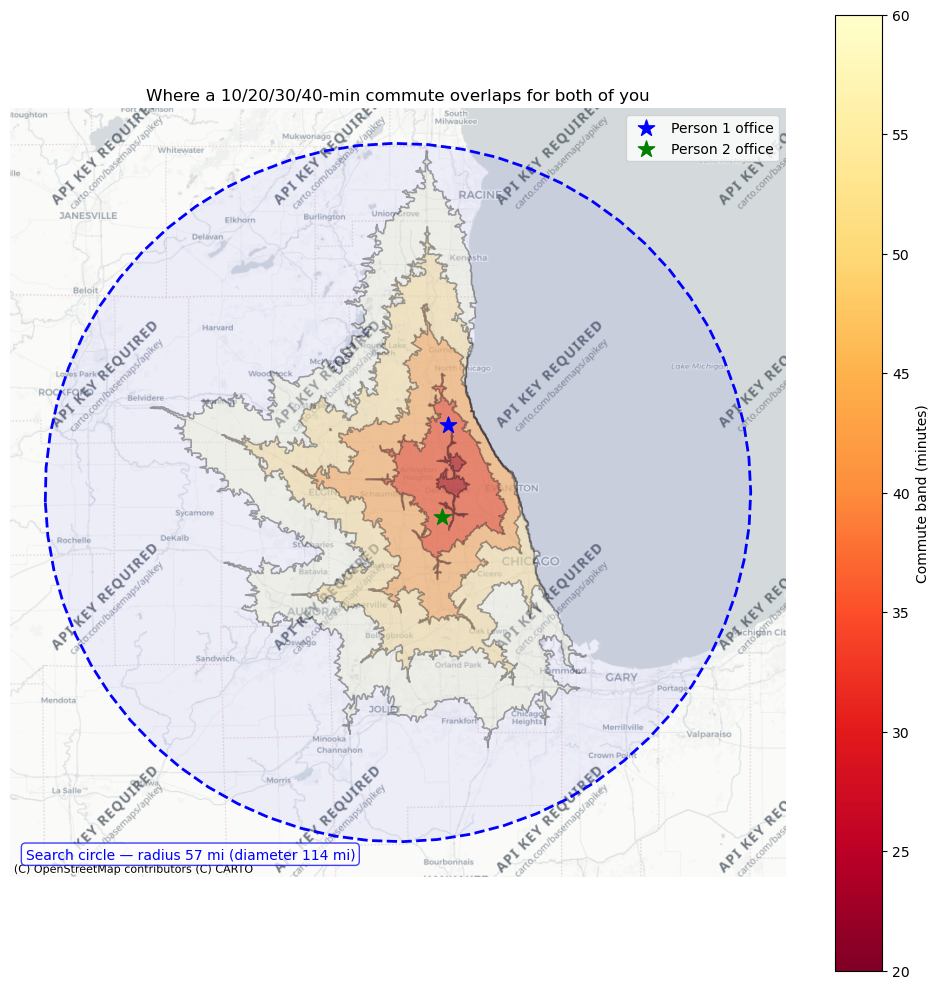

Saved to isochrone_check.png


In [107]:
plot_isochrones(
    result,
    office_lat=person1.anchor_lat, office_lon=person1.anchor_lon,
    office2_lat=person2.anchor_lat, office2_lon=person2.anchor_lon,
    title="Where a 10/20/30/40-min commute overlaps for both of you",
    circle_center_lat=circle_center_lat,
    circle_center_lon=circle_center_lon,
    circle_radius_miles=circle_radius_miles,
)

# Huds Dataset Alternative 

Real, live rental listings (via RentCast) inside the search circle above, then filtered with true point-in-polygon geometry down to only the listings that are ACTUALLY inside the real commute boundary — the circle is deliberately oversized to guarantee full coverage, so this filtering step removes anything that was in the circle but not really within a reachable commute band.

This replaces an earlier version of this project that used HUD's Small Area Fair Market Rent (SAFMR) data — a real, useful government dataset, but a zip-code-level *statistical estimate* (the 40th percentile of rents), not a real listing. Real listings are strictly better for this purpose wherever they're available.


In [108]:
import requests
import pandas as pd

# ══════════════════════════════════════════════════════════════════
# HUD Dataset Alternative — pull ALL active rental listings inside the
# one confirmed circle (center + radius from the cells above).
# ══════════════════════════════════════════════════════════════════

RENTCAST_BASE_URL = "https://api.rentcast.io/v1/listings/rental/long-term"


def fetch_rentcast_listings(lat, lon, radius, api_key, status="Active"):
    """Pull ALL active rental listings within `radius` miles of (lat, lon),
    paginating automatically if there are more than 500 results."""
    headers = {"X-Api-Key": api_key}
    all_listings = []
    offset = 0
    limit = 500

    while True:
        params = {
            "latitude": lat,
            "longitude": lon,
            "radius": radius,
            "status": status,
            "limit": limit,
            "offset": offset,
            "includeTotalCount": "true",
        }
        response = requests.get(RENTCAST_BASE_URL, headers=headers, params=params)
        if response.status_code != 200:
            raise RuntimeError(f"RentCast request failed ({response.status_code}): {response.text}")

        batch = response.json()
        all_listings.extend(batch)

        total_count = int(response.headers.get("X-Total-Count", len(batch)))
        offset += limit
        print(f"  fetched {len(all_listings)} of {total_count}")

        if offset >= total_count or not batch:
            break

    return all_listings


print(f"Searching {circle_radius_miles} mi around ({circle_center_lat:.5f}, {circle_center_lon:.5f})...")
listings = fetch_rentcast_listings(circle_center_lat, circle_center_lon, circle_radius_miles, rentcast_api)

raw_listings_df = pd.DataFrame(listings)
print(f"\nTotal listings retrieved: {len(raw_listings_df)}")
print(f"Columns returned: {list(raw_listings_df.columns)}")
display(raw_listings_df.head(10))

Searching 57 mi around (42.03020, -88.04429)...
  fetched 500 of 17671
  fetched 1000 of 17671
  fetched 1500 of 17671
  fetched 2000 of 17671
  fetched 2500 of 17671
  fetched 3000 of 17671
  fetched 3500 of 17671
  fetched 4000 of 17671
  fetched 4500 of 17671
  fetched 5000 of 17671
  fetched 5500 of 17671
  fetched 6000 of 17671
  fetched 6500 of 17671
  fetched 7000 of 17671
  fetched 7500 of 17671
  fetched 8000 of 17671
  fetched 8500 of 17671
  fetched 9000 of 17671
  fetched 9500 of 17671
  fetched 10000 of 17671
  fetched 10500 of 17671
  fetched 11000 of 17671
  fetched 11500 of 17671
  fetched 12000 of 17671
  fetched 12500 of 17671
  fetched 13000 of 17671
  fetched 13500 of 17671
  fetched 14000 of 17671
  fetched 14500 of 17671
  fetched 15000 of 17671
  fetched 15500 of 17671
  fetched 16000 of 17671
  fetched 16500 of 17671
  fetched 17000 of 17671
  fetched 17500 of 17671
  fetched 17671 of 17671

Total listings retrieved: 17671
Columns returned: ['id', 'formattedAddr

,id,formattedAddress,addressLine1,addressLine2,city,state,stateFips,zipCode,county,countyFips,latitude,longitude,propertyType,bedrooms,bathrooms,squareFootage,status,price,listingType,listedDate,removedDate,createdDate,lastSeenDate,daysOnMarket,history,yearBuilt,mlsName,mlsNumber,listingAgent,listingOffice,lotSize,hoa
0,"4526-N-Sheridan-Rd,-Apt-615,-Chicago,-IL-60640","4526 N Sheridan Rd, Apt 615, Chicago, IL 60640",4526 N Sheridan Rd,Apt 615,Chicago,IL,17,60640,Cook,031,41.964439,-87.655197,Apartment,0.0,1.0,300.0,Active,1200,Standard,2026-08-25T00:00:00.000Z,None,2022-07-20T02:24:39.286Z,2026-09-08T03:41:29.712Z,15,"{'2026-08-25': {'event': 'Rental Listing', 'price': 1200, 'listingType': 'Standard', 'listedDate': '2026-08-25T00:00:00.000Z', 'removedDate': None, 'daysOnMarket': 15}}",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"4526-N-Sheridan-Rd,-Apt-219,-Chicago,-IL-60640","4526 N Sheridan Rd, Apt 219, Chicago, IL 60640",4526 N Sheridan Rd,Apt 219,Chicago,IL,17,60640,Cook,031,41.964439,-87.655197,Apartment,0.0,1.0,380.0,Active,1150,Standard,2026-08-25T00:00:00.000Z,None,2022-07-24T03:32:07.256Z,2026-09-08T03:41:29.711Z,15,"{'2026-08-25': {'event': 'Rental Listing', 'price': 1150, 'listingType': 'Standard', 'listedDate': '2026-08-25T00:00:00.000Z', 'removedDate': None, 'daysOnMarket': 15}}",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"1810-N-Wells-St,-Apt-206,-Chicago,-IL-60614","1810 N Wells St, Apt 206, Chicago, IL 60614",1810 N Wells St,Apt 206,Chicago,IL,17,60614,Cook,031,41.915192,-87.635147,Apartment,2.0,2.0,1058.0,Active,5175,Standard,2026-08-25T00:00:00.000Z,None,2024-07-05T00:00:00.000Z,2026-09-08T03:41:29.710Z,15,"{'2026-08-25': {'event': 'Rental Listing', 'price': 5175, 'listingType': 'Standard', 'listedDate': '2026-08-25T00:00:00.000Z', 'removedDate': None, 'daysOnMarket': 15}}",2024.0,NaN,NaN,NaN,NaN,NaN,NaN
3,"1925-Grove-Ave,-Apt-211,-Berwyn,-IL-60402","1925 Grove Ave, Apt 211, Berwyn, IL 60402",1925 Grove Ave,Apt 211,Berwyn,IL,17,60402,Cook,031,41.852879,-87.794283,Single Family,1.0,1.0,700.0,Active,1295,Standard,2026-08-25T00:00:00.000Z,None,2022-03-18T02:37:26.818Z,2026-09-08T03:41:29.709Z,15,"{'2026-08-25': {'event': 'Rental Listing', 'price': 1295, 'listingType': 'Standard', 'listedDate': '2026-08-25T00:00:00.000Z', 'removedDate': None, 'daysOnMarket': 15}}",1925.0,MRED,12742620,"{'name': 'Alan Meltzer', 'phone': '3124012500', 'email': 'alan@meltzerre.com'}","{'name': 'Meltzer Real Estate Llc', 'phone': '7738001135', 'email': 'alan@meltzerre.com', 'website': 'www.meltzerrre.com'}",NaN,NaN
4,"5852-S-King-Dr,-Apt-3,-Chicago,-IL-60637","5852 S King Dr, Apt 3, Chicago, IL 60637",5852 S King Dr,Apt 3,Chicago,IL,17,60637,Cook,031,41.787777,-87.616112,Apartment,2.0,1.0,650.0,Active,1500,Standard,2026-08-25T00:00:00.000Z,None,2026-08-26T00:00:00.000Z,2026-09-08T03:41:29.709Z,15,"{'2026-08-25': {'event': 'Rental Listing', 'price': 1500, 'listingType': 'Standard', 'listedDate': '2026-08-25T00:00:00.000Z', 'removedDate': None, 'daysOnMarket': 15}}",NaN,MRED,12742608,"{'name': 'Karel Machala', 'phone': '6307688884', 'email': 'karl@606realty.com'}","{'name': '606 Realty Llc', 'phone': '7732058300'}",NaN,NaN
5,"1720-Maple-Ave,-Apt-409,-Evanston,-IL-60201","1720 Maple Ave, Apt 409, Evanston, IL 60201",1720 Maple Ave,Apt 409,Evanston,IL,17,60201,Cook,031,42.049394,-87.685331,Condo,1.0,1.0,900.0,Active,2475,Standard,2026-08-25T00:00:00.000Z,None,2020-06-17T07:08:18.288Z,2026-09-08T03:41:29.708Z,15,"{'2024-11-15': {'event': 'Rental Listing', 'price': 2200, 'listingType': 'Standard', 'listedDate': '2024-11-15T00:00:00.000Z', 'removedDate': '2025-01-23T00:00:00.000Z', 'daysOnMarket': 69}, '2026-08-25': {'event': 'Rental Listing', 'price': 2475, 'listingType': 'Standard', 'listedDate': '2026-08-25T00:00:00.000Z', 'removedDate': None, 'daysOnMarket': 15}}",2003.0,MRED,12742599,"{'name': 'Michael Marin', 'phone': '8473121014', 'email': 'michael@signaturehomesrealty.net'}","{'name': 'Signature Homes Realty', 'phone': '8473121014', 'email': 'broker@michaelma

In [110]:
import geopandas as gpd

# ══════════════════════════════════════════════════════════════════
# listings_in_bands — drops any address that was inside the search
# CIRCLE but outside the actual 60-minute commute boundary. Since the
# bands are nested (60-min area contains everything reachable in 40,
# 30, 20, 10 min too), testing against just the largest band tells you
# "is this inside ANY band."
# ══════════════════════════════════════════════════════════════════

outer_band = max(result.keys())
outer_polygon = result[outer_band]

listings_in_bands = raw_listings_df.dropna(subset=["latitude", "longitude"]).copy()

geometry = gpd.points_from_xy(listings_in_bands["longitude"], listings_in_bands["latitude"])
listings_gdf = gpd.GeoDataFrame(listings_in_bands, geometry=geometry, crs="EPSG:4326")

inside_mask = listings_gdf.within(outer_polygon)
listings_in_bands = listings_in_bands[inside_mask].reset_index(drop=True)

print(f"Started with {len(raw_listings_df)} listings from the circle")
print(f"{len(listings_in_bands)} actually fall inside the 60-minute boundary")
print(f"Dropped {len(raw_listings_df) - len(listings_in_bands)} listings that were in the circle but outside the real isochrone")

display(listings_in_bands.head(10))

Started with 17671 listings from the circle
16163 actually fall inside the 60-minute boundary
Dropped 1508 listings that were in the circle but outside the real isochrone


,id,formattedAddress,addressLine1,addressLine2,city,state,stateFips,zipCode,county,countyFips,latitude,longitude,propertyType,bedrooms,bathrooms,squareFootage,status,price,listingType,listedDate,removedDate,createdDate,lastSeenDate,daysOnMarket,history,yearBuilt,mlsName,mlsNumber,listingAgent,listingOffice,lotSize,hoa
0,"4526-N-Sheridan-Rd,-Apt-615,-Chicago,-IL-60640","4526 N Sheridan Rd, Apt 615, Chicago, IL 60640",4526 N Sheridan Rd,Apt 615,Chicago,IL,17,60640,Cook,031,41.964439,-87.655197,Apartment,0.0,1.0,300.0,Active,1200,Standard,2026-08-25T00:00:00.000Z,None,2022-07-20T02:24:39.286Z,2026-09-08T03:41:29.712Z,15,"{'2026-08-25': {'event': 'Rental Listing', 'price': 1200, 'listingType': 'Standard', 'listedDate': '2026-08-25T00:00:00.000Z', 'removedDate': None, 'daysOnMarket': 15}}",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"4526-N-Sheridan-Rd,-Apt-219,-Chicago,-IL-60640","4526 N Sheridan Rd, Apt 219, Chicago, IL 60640",4526 N Sheridan Rd,Apt 219,Chicago,IL,17,60640,Cook,031,41.964439,-87.655197,Apartment,0.0,1.0,380.0,Active,1150,Standard,2026-08-25T00:00:00.000Z,None,2022-07-24T03:32:07.256Z,2026-09-08T03:41:29.711Z,15,"{'2026-08-25': {'event': 'Rental Listing', 'price': 1150, 'listingType': 'Standard', 'listedDate': '2026-08-25T00:00:00.000Z', 'removedDate': None, 'daysOnMarket': 15}}",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"1810-N-Wells-St,-Apt-206,-Chicago,-IL-60614","1810 N Wells St, Apt 206, Chicago, IL 60614",1810 N Wells St,Apt 206,Chicago,IL,17,60614,Cook,031,41.915192,-87.635147,Apartment,2.0,2.0,1058.0,Active,5175,Standard,2026-08-25T00:00:00.000Z,None,2024-07-05T00:00:00.000Z,2026-09-08T03:41:29.710Z,15,"{'2026-08-25': {'event': 'Rental Listing', 'price': 5175, 'listingType': 'Standard', 'listedDate': '2026-08-25T00:00:00.000Z', 'removedDate': None, 'daysOnMarket': 15}}",2024.0,NaN,NaN,NaN,NaN,NaN,NaN
3,"1925-Grove-Ave,-Apt-211,-Berwyn,-IL-60402","1925 Grove Ave, Apt 211, Berwyn, IL 60402",1925 Grove Ave,Apt 211,Berwyn,IL,17,60402,Cook,031,41.852879,-87.794283,Single Family,1.0,1.0,700.0,Active,1295,Standard,2026-08-25T00:00:00.000Z,None,2022-03-18T02:37:26.818Z,2026-09-08T03:41:29.709Z,15,"{'2026-08-25': {'event': 'Rental Listing', 'price': 1295, 'listingType': 'Standard', 'listedDate': '2026-08-25T00:00:00.000Z', 'removedDate': None, 'daysOnMarket': 15}}",1925.0,MRED,12742620,"{'name': 'Alan Meltzer', 'phone': '3124012500', 'email': 'alan@meltzerre.com'}","{'name': 'Meltzer Real Estate Llc', 'phone': '7738001135', 'email': 'alan@meltzerre.com', 'website': 'www.meltzerrre.com'}",NaN,NaN
4,"5852-S-King-Dr,-Apt-3,-Chicago,-IL-60637","5852 S King Dr, Apt 3, Chicago, IL 60637",5852 S King Dr,Apt 3,Chicago,IL,17,60637,Cook,031,41.787777,-87.616112,Apartment,2.0,1.0,650.0,Active,1500,Standard,2026-08-25T00:00:00.000Z,None,2026-08-26T00:00:00.000Z,2026-09-08T03:41:29.709Z,15,"{'2026-08-25': {'event': 'Rental Listing', 'price': 1500, 'listingType': 'Standard', 'listedDate': '2026-08-25T00:00:00.000Z', 'removedDate': None, 'daysOnMarket': 15}}",NaN,MRED,12742608,"{'name': 'Karel Machala', 'phone': '6307688884', 'email': 'karl@606realty.com'}","{'name': '606 Realty Llc', 'phone': '7732058300'}",NaN,NaN
5,"1720-Maple-Ave,-Apt-409,-Evanston,-IL-60201","1720 Maple Ave, Apt 409, Evanston, IL 60201",1720 Maple Ave,Apt 409,Evanston,IL,17,60201,Cook,031,42.049394,-87.685331,Condo,1.0,1.0,900.0,Active,2475,Standard,2026-08-25T00:00:00.000Z,None,2020-06-17T07:08:18.288Z,2026-09-08T03:41:29.708Z,15,"{'2024-11-15': {'event': 'Rental Listing', 'price': 2200, 'listingType': 'Standard', 'listedDate': '2024-11-15T00:00:00.000Z', 'removedDate': '2025-01-23T00:00:00.000Z', 'daysOnMarket': 69}, '2026-08-25': {'event': 'Rental Listing', 'price': 2475, 'listingType': 'Standard', 'listedDate': '2026-08-25T00:00:00.000Z', 'removedDate': None, 'daysOnMarket': 15}}",2003.0,MRED,12742599,"{'name': 'Michael Marin', 'phone': '8473121014', 'email': 'michael@signaturehomesrealty.net'}","{'name': 'Signature Homes Realty', 'phone': '8473121014', 'email': 'broker@michaelma

# Report Builder Engine

Joins the real commute data to the real listing data — **by address, not zip code**, since multiple buildings can share a zip and address is the only safe join key once you're working with real listings — and computes every financial figure the final report needs: income/debt/expense splits under two philosophies (50/50 and income-proportional), monthly outflow and leftover per person, and the landlord-screening income basis.


In [111]:
import geopandas as gpd
from tqdm import tqdm

# ══════════════════════════════════════════════════════════════════
# Dedupe listings down to unique BUILDINGS — multiple units at the same
# address share the same lat/lon, so commute only needs to be computed
# ONCE per building, not once per listing.
# ══════════════════════════════════════════════════════════════════

unique_addresses = (
    listings_in_bands
    .dropna(subset=["addressLine1", "latitude", "longitude", "zipCode"])
    .drop_duplicates(subset="addressLine1")
    [["addressLine1", "zipCode", "latitude", "longitude"]]
    .rename(columns={"zipCode": "Zip Code"})
    .reset_index(drop=True)
)

print(f"{len(listings_in_bands)} listings -> {len(unique_addresses)} unique building addresses "
      f"(commute only needs to be computed once per building)")

# --- Assign each address its Commute Band — this preserves exactly
#     what your old zip-classification pipeline gave you (a band label
#     per location), just computed directly against the real address
#     instead of a zip centroid. Tests each point against the same
#     cumulative isochrone polygons in `result`, finding the smallest
#     band whose shape actually contains that point. ---
geometry = gpd.points_from_xy(unique_addresses["longitude"], unique_addresses["latitude"])
addresses_gdf = gpd.GeoDataFrame(unique_addresses, geometry=geometry, crs="EPSG:4326")

def assign_band(point_geom):
    for band in sorted(result.keys()):
        if result[band].contains(point_geom):
            return f"{band} min"
    return None

unique_addresses["Commute Band"] = addresses_gdf.geometry.apply(assign_band)
unique_addresses = unique_addresses.dropna(subset=["Commute Band"]).reset_index(drop=True)

# ══════════════════════════════════════════════════════════════════
# Commute per unique address — SAME get_route_with_congestion /
# leg_cost_with_congestion functions as before. Office locations
# (person1/person2 anchors) are unchanged; only the DESTINATION
# coordinates now come from listings_in_bands instead of a pgeocode
# zip-centroid lookup.
# ══════════════════════════════════════════════════════════════════

p1_lat, p1_lon = person1.anchor_lat, person1.anchor_lon
p1_arrival = getattr(person1, "required_arrival_iso", None)

d1_list, t1_list, c1_list, cong1_list = [], [], [], []
print("Calculating Mapbox routes for Person 1 (Losha)...")
for _, row in tqdm(unique_addresses.iterrows(), total=len(unique_addresses), desc="Person 1 Commute"):
  dist, time, cong_min = get_route_with_congestion(
      p1_lon, p1_lat, row["longitude"], row["latitude"], mapbox_token, p1_arrival
  )
  if dist is not None:
    leg_cost = leg_cost_with_congestion(dist, cost_one, cong_min)
    d1_list.append(round(dist, 1))
    t1_list.append(round(time, 1))
    c1_list.append(round(leg_cost * 2, 2))
    cong1_list.append(round(cong_min, 1) if cong_min is not None else None)
  else:
    d1_list.append(None); t1_list.append(None); c1_list.append(None); cong1_list.append(None)

unique_addresses["distance_person1"] = d1_list
unique_addresses["commute_time_person1"] = t1_list
unique_addresses["roundtrip_commute_cost_person1"] = c1_list
unique_addresses["congestion_minutes_person1"] = cong1_list

# Person 2
p2_lat, p2_lon = person2.anchor_lat, person2.anchor_lon
p2_arrival = getattr(person2, "required_arrival_iso", None)

d2_list, t2_list, c2_list, cong2_list = [], [], [], []
print("Calculating Mapbox routes for Person 2 (Vika)...")
for _, row in tqdm(unique_addresses.iterrows(), total=len(unique_addresses), desc="Person 2 Commute"):
  dist, time, cong_min = get_route_with_congestion(
      p2_lon, p2_lat, row["longitude"], row["latitude"], mapbox_token, p2_arrival
  )
  if dist is not None:
    leg_cost = leg_cost_with_congestion(dist, cost_two, cong_min)
    d2_list.append(round(dist, 1))
    t2_list.append(round(time, 1))
    c2_list.append(round(leg_cost * 2, 2))
    cong2_list.append(round(cong_min, 1) if cong_min is not None else None)
  else:
    d2_list.append(None); t2_list.append(None); c2_list.append(None); cong2_list.append(None)

unique_addresses["distance_person2"] = d2_list
unique_addresses["commute_time_person2"] = t2_list
unique_addresses["roundtrip_commute_cost_person2"] = c2_list
unique_addresses["congestion_minutes_person2"] = cong2_list

unique_addresses = unique_addresses.dropna(subset=["distance_person1", "distance_person2"]).reset_index(drop=True)

unique_addresses["commute_cost_combined"] = (
    unique_addresses["roundtrip_commute_cost_person1"] + unique_addresses["roundtrip_commute_cost_person2"]
).round(2)

# --- Final shape — same columns as before, PLUS Address inserted
#     to the left of Zip Code ---
unique_addresses = unique_addresses.rename(columns={"addressLine1": "Address"})

couple_commute_df = unique_addresses[[
    "Commute Band", "Address", "Zip Code",
    "distance_person1", "commute_time_person1", "roundtrip_commute_cost_person1", "congestion_minutes_person1",
    "distance_person2", "commute_time_person2", "roundtrip_commute_cost_person2", "congestion_minutes_person2",
    "commute_cost_combined",
]].reset_index(drop=True)

display(couple_commute_df.head(10))

16163 listings -> 8401 unique building addresses (commute only needs to be computed once per building)
Calculating Mapbox routes for Person 1 (Losha)...


Person 1 Commute: 100%|█████████████████████████████████████████████████████████████████████████| 8401/8401 [1:37:23<00:00,  1.44it/s]


Calculating Mapbox routes for Person 2 (Vika)...


Person 2 Commute: 100%|█████████████████████████████████████████████████████████████████████████| 8401/8401 [1:33:33<00:00,  1.50it/s]


,Commute Band,Address,Zip Code,distance_person1,commute_time_person1,roundtrip_commute_cost_person1,congestion_minutes_person1,distance_person2,commute_time_person2,roundtrip_commute_cost_person2,congestion_minutes_person2,commute_cost_combined
0,50 min,4526 N Sheridan Rd,60640,26.6,71.5,8.59,13.5,16.8,52.8,4.05,0.0,12.64
1,50 min,1810 N Wells St,60614,30.6,76.4,9.86,15.0,20.8,58.5,5.05,2.8,14.91
2,50 min,1925 Grove Ave,60402,29.7,69.6,9.47,9.6,14.3,41.2,3.45,0.0,12.92
3,60 min,5852 S King Dr,60637,40.9,102.2,13.38,30.7,25.0,65.4,6.02,0.0,19.40
4,40 min,1720 Maple Ave,60201,18.8,42.1,5.95,4.0,17.3,39.5,4.17,0.0,10.12
5,40 min,1228 Emerson St,60201,18.4,39.6,5.82,3.6,16.9,37.3,4.07,0.0,9.89
6,50 min,4706 N Beacon St,60640,25.2,67.9,8.12,12.2,13.8,48.3,3.33,0.0,11.45
7,50 min,624 W Surf St,60657,28.9,76.1,9.33,15.1,15.4,56.7,3.75,1.9,13.08
8,60 min,5524 S Paulina St,60636,41.7,105.5,13.66,31.2,28.2,66.4,6.81,0.0,20.47
9,40 min,1711 W Estes Ave,60626,23.2,56.0,7.48,11.3,14.7,47.0,3.55,0.0,11.03


In [60]:
individual_1_on_lease = True
individual_2_on_lease = True   # e.g. only Individual 1 is legally on the lease — flip either any time

In [119]:
import numpy as np
import pandas as pd

# ══════════════════════════════════════════════════════════════════
# Rent Bands — REAL-LISTING version. rent_bedroom_preference is gone
# entirely (each listing already has its own bedroom count).
# individual_1_on_lease / individual_2_on_lease are STILL needed —
# On Lease Person 1/2 and both Landlord Screening columns below are
# computed directly from these two variables.
# ══════════════════════════════════════════════════════════════════

individual_1_on_lease = True
individual_2_on_lease = True   # flip either any time

required_vars = ["net1_annual", "net2_annual", "gross1_annual", "gross2_annual"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(
        f"Missing {missing} — run the income calculator cell (analyze(...)) first."
    )

total_net_income = net1_annual + net2_annual
prop1_ratio = net1_annual / total_net_income if total_net_income > 0 else 0.5
prop2_ratio = net2_annual / total_net_income if total_net_income > 0 else 0.5

# 1. Bring in the Commute Band each listing's BUILDING already has, from
#    couple_commute_df (joined by address — multiple units at the same
#    building all inherit that building's one commute result).
rent_bands = listings_in_bands.merge(
    couple_commute_df[["Address", "Commute Band"]],
    left_on="addressLine1", right_on="Address", how="inner",
)

# 2. Rent Cost Total is the REAL listing price — no zip lookup needed
rent_bands["Rent Cost Total"] = rent_bands["price"].astype(float)
rent_bands = rent_bands.dropna(subset=["Rent Cost Total"])

# 3. 50/50 and Proportionate splits — same math as before, now against
#    a real per-unit rent instead of a zip-level estimate
rent_bands["50/50 Rent Cost"] = (rent_bands["Rent Cost Total"] / 2.0).round(2)
rent_bands["Proportionate Cost Person 1"] = (rent_bands["Rent Cost Total"] * prop1_ratio).round(2)
rent_bands["Proportionate Cost Person 2"] = (rent_bands["Rent Cost Total"] * prop2_ratio).round(2)

# 4. Lease status + landlord screening basis — unchanged logic
rent_bands["On Lease Person 1"] = individual_1_on_lease
rent_bands["On Lease Person 2"] = individual_2_on_lease

if individual_1_on_lease and individual_2_on_lease:
    landlord_basis_annual = gross1_annual + gross2_annual
    landlord_basis_label = "combined gross (both on lease)"
elif individual_1_on_lease:
    landlord_basis_annual = gross1_annual
    landlord_basis_label = "Person 1 gross only (sole leaseholder)"
elif individual_2_on_lease:
    landlord_basis_annual = gross2_annual
    landlord_basis_label = "Person 2 gross only (sole leaseholder)"
else:
    landlord_basis_annual = np.nan
    landlord_basis_label = "UNSET — no leaseholder flagged, check individual_1_on_lease/individual_2_on_lease"

rent_bands["Landlord Screening Income Basis"] = landlord_basis_label
rent_bands["Landlord Screening Gross Monthly"] = round(landlord_basis_annual / 12, 2) if pd.notna(landlord_basis_annual) else np.nan

# 5. Final column selection
rent_bands = rent_bands.rename(columns={"zipCode": "Zip Code"})
rent_bands = rent_bands[[
    "Commute Band",
    "Address",
    "formattedAddress",
    "Zip Code",
    "Rent Cost Total",
    "50/50 Rent Cost",
    "Proportionate Cost Person 1",
    "Proportionate Cost Person 2",
    "On Lease Person 1",
    "On Lease Person 2",
    "Landlord Screening Income Basis",
    "Landlord Screening Gross Monthly",
    "bedrooms",
    "bathrooms",
    "propertyType",
    "squareFootage",
    "listingAgent",
    "listingOffice",
]].reset_index(drop=True)

display(rent_bands.head(10))

,Commute Band,Address,formattedAddress,Zip Code,Rent Cost Total,50/50 Rent Cost,Proportionate Cost Person 1,Proportionate Cost Person 2,On Lease Person 1,On Lease Person 2,Landlord Screening Income Basis,Landlord Screening Gross Monthly,bedrooms,bathrooms,propertyType,squareFootage,listingAgent,listingOffice
0,50 min,4526 N Sheridan Rd,"4526 N Sheridan Rd, Apt 615, Chicago, IL 60640",60640,1200.0,600.0,697.53,502.47,True,True,combined gross (both on lease),17420.0,0.0,1.0,Apartment,300.0,NaN,NaN
1,50 min,4526 N Sheridan Rd,"4526 N Sheridan Rd, Apt 219, Chicago, IL 60640",60640,1150.0,575.0,668.46,481.54,True,True,combined gross (both on lease),17420.0,0.0,1.0,Apartment,380.0,NaN,NaN
2,50 min,1810 N Wells St,"1810 N Wells St, Apt 206, Chicago, IL 60614",60614,5175.0,2587.5,3008.08,2166.92,True,True,combined gross (both on lease),17420.0,2.0,2.0,Apartment,1058.0,NaN,NaN
3,50 min,1925 Grove Ave,"1925 Grove Ave, Apt 211, Berwyn, IL 60402",60402,1295.0,647.5,752.75,542.25,True,True,combined gross (both on lease),17420.0,1.0,1.0,Single Family,700.0,"{'name': 'Alan Meltzer', 'phone': '3124012500', 'email': 'alan@meltzerre.com'}","{'name': 'Meltzer Real Estate Llc', 'phone': '7738001135', 'email': 'alan@meltzerre.com', 'website': 'www.meltzerrre.com'}"
4,60 min,5852 S King Dr,"5852 S King Dr, Apt 3, Chicago, IL 60637",60637,1500.0,750.0,871.91,628.09,True,True,combined gross (both on lease),17420.0,2.0,1.0,Apartment,650.0,"{'name': 'Karel Machala', 'phone': '6307688884', 'email': 'karl@606realty.com'}","{'name': '606 Realty Llc', 'phone': '7732058300'}"
5,40 min,1720 Maple Ave,"1720 Maple Ave, Apt 409, Evanston, IL 60201",60201,2475.0,1237.5,1438.65,1036.35,True,True,combined gross (both on lease),17420.0,1.0,1.0,Condo,900.0,"{'name': 'Michael Marin', 'phone': '8473121014', 'email': 'michael@signaturehomesrealty.net'}","{'name': 'Signature Homes Realty', 'phone': '8473121014', 'email': 'broker@michaelmarin.net'}"
6,40 min,1228 Emerson St,"1228 Emerson St, Unit 202, Evanston, IL 60201",60201,3500.0,1750.0,2034.45,1465.55,True,True,combined gross (both on lease),17420.0,1.0,1.0,Single Family,964.0,"{'name': 'Rene Millan', 'phone': '2623255160', 'email': 'renemillan@atproperties.com'}","{'name': '@properties Evanston', 'phone': '8477630200', 'email': 'realtordotcomleads@atproperties.com', 'website': 'https://www.atproperties.com/offices/'}"
7,50 min,4706 N Beacon St,"4706 N Beacon St, Chicago, IL 60640",60640,995.0,497.5,578.36,416.64,True,True,combined gross (both on lease),17420.0,0.0,1.0,Apartment,450.0,NaN,NaN
8,50 min,624 W Surf St,"624 W Surf St, Chicago, IL 60657",60657,1450.0,725.0,842.84,607.16,True,True,combined gross (both on lease),17420.0,0.0,1.0,Apartment,450.0,NaN,NaN
9,60 min,5524 S Paulina St,"5524 S Paulina St, Unit 1, Chicago, IL 60636",60636,1950.0,975.0,1133.48,816.52,True,True,combined gross (both on lease),17420.0,3.0,1.0,Single Family,1200.0,"{'name': 'Florentino Perez', 'phone': '7737358000', 'email': 'tony@mcprealtor.com'}","{'name': 'eXp Realty', 'phone': '8885749405', 'email': 'il.broker@exprealty.net', 'website': 'https://il.exprealty.com/'}"


# Report

The final table: one row per real, live listing, showing whether it's financially **Feasible**, **Safe** even in a worst-case income-loss scenario, **Responsible** under standard 36% debt-to-income guidance, and likely to clear **landlord screening** under three different lease-signing scenarios — since who signs determines both who a landlord checks and who's legally exposed if the arrangement breaks down.


In [121]:
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# ══════════════════════════════════════════════════════════════════
# PART 1 — Aggregate debts & expenses ONCE.
# ══════════════════════════════════════════════════════════════════

def aggregate_debts(slots, prop1_ratio, prop2_ratio):
    individual_p1 = individual_p2 = shared_total = 0.0
    for s in slots:
        if not s.include:
            continue
        payment = s.monthly_payment()
        if s.person_one and s.person_two:
            shared_total += payment
        elif s.person_one:
            individual_p1 += payment
        elif s.person_two:
            individual_p2 += payment
    return {
        "individual_p1": round(individual_p1, 2),
        "individual_p2": round(individual_p2, 2),
        "shared_total": round(shared_total, 2),
        "shared_5050_share": round(shared_total / 2, 2),
        "shared_proportional_p1": round(shared_total * prop1_ratio, 2),
        "shared_proportional_p2": round(shared_total * prop2_ratio, 2),
    }


def aggregate_expenses(slots, prop1_ratio, prop2_ratio):
    individual_p1 = individual_p2 = shared_total = 0.0
    for s in slots:
        if not s.include:
            continue
        amount = s.resolved_amount()
        if s.person_oden and s.person_dva:
            shared_total += amount
        elif s.person_oden:
            individual_p1 += amount
        elif s.person_dva:
            individual_p2 += amount
    return {
        "individual_p1": round(individual_p1, 2),
        "individual_p2": round(individual_p2, 2),
        "shared_total": round(shared_total, 2),
        "shared_5050_share": round(shared_total / 2, 2),
        "shared_proportional_p1": round(shared_total * prop1_ratio, 2),
        "shared_proportional_p2": round(shared_total * prop2_ratio, 2),
    }


debts_agg = aggregate_debts(
    [debt1, debt2, debt3, debt4, debt5, debt6, debt7, debt8, debt9, debt10,
     debt11, debt12, debt13, debt14, debt15, debt16, debt17, debt18, debt19, debt20],
    prop1_ratio, prop2_ratio,
)
expenses_agg = aggregate_expenses(
    [groceries, auto_insurance, health_insurance, renters_insurance, gas_fuel, phone],
    prop1_ratio, prop2_ratio,
)

print("Debts   :", debts_agg)
print("Expenses:", expenses_agg)


# ══════════════════════════════════════════════════════════════════
# PART 2 — Join commute + rent (NOW keyed by Address, not Zip Code),
# broadcast income/debts/expenses, compute outflow/leftover per split
# method, Responsible/Worst-Case/Landlord Screening/Safety, then add
# the real listing columns (Property Info, listingAgent, listingOffice).
# ══════════════════════════════════════════════════════════════════

WEEKS_PER_MONTH = 52 / 12

report_df = couple_commute_df.merge(rent_bands, on=["Commute Band", "Address"], how="inner")

report_df["Monthly Commute Cost Person 1"] = (
    report_df["roundtrip_commute_cost_person1"] * person1.commute_days_per_week * WEEKS_PER_MONTH
).round(2)
report_df["Monthly Commute Cost Person 2"] = (
    report_df["roundtrip_commute_cost_person2"] * person2.commute_days_per_week * WEEKS_PER_MONTH
).round(2)
report_df["Monthly Commute Cost Combined"] = (
    report_df["Monthly Commute Cost Person 1"] + report_df["Monthly Commute Cost Person 2"]
).round(2)

report_df["Gross Monthly Income Person 1"] = round(gross1_annual / 12, 2)
report_df["Gross Monthly Income Person 2"] = round(gross2_annual / 12, 2)
report_df["Net Monthly Income Person 1"] = round(net1_annual / 12, 2)
report_df["Net Monthly Income Person 2"] = round(net2_annual / 12, 2)

report_df["Debts Individual Person 1"] = debts_agg["individual_p1"]
report_df["Debts Individual Person 2"] = debts_agg["individual_p2"]
report_df["Debts Shared Total"] = debts_agg["shared_total"]
report_df["Debts Shared 50/50 Share"] = debts_agg["shared_5050_share"]
report_df["Debts Shared Proportional Person 1"] = debts_agg["shared_proportional_p1"]
report_df["Debts Shared Proportional Person 2"] = debts_agg["shared_proportional_p2"]

report_df["Expenses Individual Person 1"] = expenses_agg["individual_p1"]
report_df["Expenses Individual Person 2"] = expenses_agg["individual_p2"]
report_df["Expenses Shared Total"] = expenses_agg["shared_total"]
report_df["Expenses Shared 50/50 Share"] = expenses_agg["shared_5050_share"]
report_df["Expenses Shared Proportional Person 1"] = expenses_agg["shared_proportional_p1"]
report_df["Expenses Shared Proportional Person 2"] = expenses_agg["shared_proportional_p2"]

report_df["Outflow Person 1 (50/50)"] = (
    report_df["50/50 Rent Cost"] + report_df["Debts Individual Person 1"]
    + report_df["Debts Shared 50/50 Share"] + report_df["Expenses Individual Person 1"]
    + report_df["Expenses Shared 50/50 Share"] + report_df["Monthly Commute Cost Person 1"]
).round(2)
report_df["Outflow Person 2 (50/50)"] = (
    report_df["50/50 Rent Cost"] + report_df["Debts Individual Person 2"]
    + report_df["Debts Shared 50/50 Share"] + report_df["Expenses Individual Person 2"]
    + report_df["Expenses Shared 50/50 Share"] + report_df["Monthly Commute Cost Person 2"]
).round(2)
report_df["Outflow Person 1 (Proportional)"] = (
    report_df["Proportionate Cost Person 1"] + report_df["Debts Individual Person 1"]
    + report_df["Debts Shared Proportional Person 1"] + report_df["Expenses Individual Person 1"]
    + report_df["Expenses Shared Proportional Person 1"] + report_df["Monthly Commute Cost Person 1"]
).round(2)
report_df["Outflow Person 2 (Proportional)"] = (
    report_df["Proportionate Cost Person 2"] + report_df["Debts Individual Person 2"]
    + report_df["Debts Shared Proportional Person 2"] + report_df["Expenses Individual Person 2"]
    + report_df["Expenses Shared Proportional Person 2"] + report_df["Monthly Commute Cost Person 2"]
).round(2)
report_df["Outflow Combined"] = (
    report_df["Rent Cost Total"] + report_df["Debts Individual Person 1"] + report_df["Debts Individual Person 2"]
    + 2 * report_df["Debts Shared 50/50 Share"] + report_df["Expenses Individual Person 1"]
    + report_df["Expenses Individual Person 2"] + 2 * report_df["Expenses Shared 50/50 Share"]
    + report_df["Monthly Commute Cost Combined"]
).round(2)

report_df["Leftover Person 1 (50/50)"] = (report_df["Net Monthly Income Person 1"] - report_df["Outflow Person 1 (50/50)"]).round(2)
report_df["Leftover Person 2 (50/50)"] = (report_df["Net Monthly Income Person 2"] - report_df["Outflow Person 2 (50/50)"]).round(2)
report_df["Leftover Person 1 (Proportional)"] = (report_df["Net Monthly Income Person 1"] - report_df["Outflow Person 1 (Proportional)"]).round(2)
report_df["Leftover Person 2 (Proportional)"] = (report_df["Net Monthly Income Person 2"] - report_df["Outflow Person 2 (Proportional)"]).round(2)
report_df["Leftover Combined"] = (
    report_df["Net Monthly Income Person 1"] + report_df["Net Monthly Income Person 2"] - report_df["Outflow Combined"]
).round(2)
report_df["Feasible"] = report_df["Leftover Combined"] > 0

_hd_p1_5050 = ((report_df["50/50 Rent Cost"] + report_df["Debts Individual Person 1"] + report_df["Debts Shared 50/50 Share"]) / report_df["Gross Monthly Income Person 1"] * 100).round(1)
_hd_p2_5050 = ((report_df["50/50 Rent Cost"] + report_df["Debts Individual Person 2"] + report_df["Debts Shared 50/50 Share"]) / report_df["Gross Monthly Income Person 2"] * 100).round(1)
_hd_p1_prop = ((report_df["Proportionate Cost Person 1"] + report_df["Debts Individual Person 1"] + report_df["Debts Shared Proportional Person 1"]) / report_df["Gross Monthly Income Person 1"] * 100).round(1)
_hd_p2_prop = ((report_df["Proportionate Cost Person 2"] + report_df["Debts Individual Person 2"] + report_df["Debts Shared Proportional Person 2"]) / report_df["Gross Monthly Income Person 2"] * 100).round(1)

report_df["Responsible Person 1"] = (
    "Split: " + _hd_p1_5050.map(lambda x: f"{x}%") + " = " + (_hd_p1_5050 <= 36).map({True: "Responsible", False: "Not Responsible"})
    + "\n" + "Proportional: " + _hd_p1_prop.map(lambda x: f"{x}%") + " = " + (_hd_p1_prop <= 36).map({True: "Responsible", False: "Not Responsible"})
)
report_df["Responsible Person 2"] = (
    "Split: " + _hd_p2_5050.map(lambda x: f"{x}%") + " = " + (_hd_p2_5050 <= 36).map({True: "Responsible", False: "Not Responsible"})
    + "\n" + "Proportional: " + _hd_p2_prop.map(lambda x: f"{x}%") + " = " + (_hd_p2_prop <= 36).map({True: "Responsible", False: "Not Responsible"})
)

_wc_hd_p1 = ((report_df["Rent Cost Total"] + report_df["Debts Individual Person 1"] + report_df["Debts Shared Total"]) / report_df["Gross Monthly Income Person 1"] * 100).round(1)
_wc_hd_p2 = ((report_df["Rent Cost Total"] + report_df["Debts Individual Person 2"] + report_df["Debts Shared Total"]) / report_df["Gross Monthly Income Person 2"] * 100).round(1)
_wc_responsible_p1 = _wc_hd_p1 <= 36
_wc_responsible_p2 = _wc_hd_p2 <= 36

report_df["Worst-Case Responsible Person 1"] = _wc_hd_p1.map(lambda x: f"{x}%") + " = " + _wc_responsible_p1.map({True: "Responsible", False: "Not Responsible"})
report_df["Worst-Case Responsible Person 2"] = _wc_hd_p2.map(lambda x: f"{x}%") + " = " + _wc_responsible_p2.map({True: "Responsible", False: "Not Responsible"})

report_df["Worst-Case Leftover Person 1"] = (
    report_df["Net Monthly Income Person 1"]
    - (report_df["Rent Cost Total"] + report_df["Debts Individual Person 1"] + report_df["Debts Shared Total"]
       + report_df["Expenses Individual Person 1"] + report_df["Expenses Shared Total"])
).round(2)
report_df["Worst-Case Leftover Person 2"] = (
    report_df["Net Monthly Income Person 2"]
    - (report_df["Rent Cost Total"] + report_df["Debts Individual Person 2"] + report_df["Debts Shared Total"]
       + report_df["Expenses Individual Person 2"] + report_df["Expenses Shared Total"])
).round(2)
report_df["Worst-Case Solvent Person 1"] = report_df["Worst-Case Leftover Person 1"] > 0
report_df["Worst-Case Solvent Person 2"] = report_df["Worst-Case Leftover Person 2"] > 0

report_df["Worst-Case Solvency Person 1"] = (
    report_df["Worst-Case Solvent Person 1"].map({True: "True", False: "False"})
    + " = " + report_df["Worst-Case Leftover Person 1"].map(lambda x: f"{x}")
)
report_df["Worst-Case Solvency Person 2"] = (
    report_df["Worst-Case Solvent Person 2"].map({True: "True", False: "False"})
    + " = " + report_df["Worst-Case Leftover Person 2"].map(lambda x: f"{x}")
)

report_df = report_df.rename(columns={
    "commute_time_person1": "Commute Time Person 1",
    "commute_time_person2": "Commute Time Person 2",
})

report_df["Landlord Screening Gross Monthly (Person 1 Only)"] = report_df["Gross Monthly Income Person 1"]
report_df["Landlord Screening Multiple (Person 1 Only)"] = (report_df["Landlord Screening Gross Monthly (Person 1 Only)"] / report_df["Rent Cost Total"]).round(2)
report_df["Landlord Screening Pass (Person 1 Only)"] = report_df["Landlord Screening Multiple (Person 1 Only)"] >= 3.0

report_df["Landlord Screening Gross Monthly (Person 2 Only)"] = report_df["Gross Monthly Income Person 2"]
report_df["Landlord Screening Multiple (Person 2 Only)"] = (report_df["Landlord Screening Gross Monthly (Person 2 Only)"] / report_df["Rent Cost Total"]).round(2)
report_df["Landlord Screening Pass (Person 2 Only)"] = report_df["Landlord Screening Multiple (Person 2 Only)"] >= 3.0

report_df["Landlord Screening Gross Monthly (Both)"] = report_df["Gross Monthly Income Person 1"] + report_df["Gross Monthly Income Person 2"]
report_df["Landlord Screening Multiple (Both)"] = (report_df["Landlord Screening Gross Monthly (Both)"] / report_df["Rent Cost Total"]).round(2)
report_df["Landlord Screening Pass (Both)"] = report_df["Landlord Screening Multiple (Both)"] >= 3.0

report_df["Landlord Screening (Person 1 Only)"] = (
    report_df["Landlord Screening Multiple (Person 1 Only)"].map(lambda x: f"{x}x")
    + " = " + report_df["Landlord Screening Pass (Person 1 Only)"].map({True: "Pass", False: "Fail"})
)
report_df["Landlord Screening (Person 2 Only)"] = (
    report_df["Landlord Screening Multiple (Person 2 Only)"].map(lambda x: f"{x}x")
    + " = " + report_df["Landlord Screening Pass (Person 2 Only)"].map({True: "Pass", False: "Fail"})
)
report_df["Landlord Screening (Both)"] = (
    report_df["Landlord Screening Multiple (Both)"].map(lambda x: f"{x}x")
    + " = " + report_df["Landlord Screening Pass (Both)"].map({True: "Pass", False: "Fail"})
)

report_df["Safety"] = (
    (report_df["Worst-Case Leftover Person 1"] >= 1000) & (report_df["Worst-Case Leftover Person 2"] >= 1000)
)

report_df = report_df.drop(columns=["Address"]).rename(columns={"formattedAddress": "Address"})

report_df["Property Info"] = (
    "Bedrooms = " + report_df["bedrooms"].map(lambda x: f"{x}")
    + "\n" + "Bathrooms = " + report_df["bathrooms"].map(lambda x: f"{x}")
    + "\n" + "PropertyType = " + report_df["propertyType"].map(lambda x: f"{x}")
    + "\n" + "squareFootage = " + report_df["squareFootage"].map(lambda x: f"{x}")
)

report_df["Rent Per Person"] = (
    "Split = " + report_df["50/50 Rent Cost"].map(lambda x: f"{x}")
    + "\n" + "Person 1 Proportionate = " + report_df["Proportionate Cost Person 1"].map(lambda x: f"{x}")
    + "\n" + "Person 2 Proportionate = " + report_df["Proportionate Cost Person 2"].map(lambda x: f"{x}")
)

report_df["Debts Per Person"] = (
    "Split = " + report_df["Debts Shared 50/50 Share"].map(lambda x: f"{x}")
    + "\n" + "Person 1 Proportionate = " + report_df["Debts Shared Proportional Person 1"].map(lambda x: f"{x}")
    + "\n" + "Person 2 Proportionate = " + report_df["Debts Shared Proportional Person 2"].map(lambda x: f"{x}")
    + "\n" + "Total = " + report_df["Debts Shared Total"].map(lambda x: f"{x:.2f}")
)

report_df["Expenses Per Person"] = (
    "Split = " + report_df["Expenses Shared 50/50 Share"].map(lambda x: f"{x}")
    + "\n" + "Person 1 Proportionate = " + report_df["Expenses Shared Proportional Person 1"].map(lambda x: f"{x}")
    + "\n" + "Person 2 Proportionate = " + report_df["Expenses Shared Proportional Person 2"].map(lambda x: f"{x}")
    + "\n" + "Total: " + report_df["Expenses Shared Total"].map(lambda x: f"{x:.2f}")
)

report_df["Outflow Per Person"] = (
    "Split Person 1 = " + report_df["Outflow Person 1 (50/50)"].map(lambda x: f"{x}")
    + "\n" + "Split Person 2 = " + report_df["Outflow Person 2 (50/50)"].map(lambda x: f"{x}")
    + "\n" + "Person 1 Proportionate = " + report_df["Outflow Person 1 (Proportional)"].map(lambda x: f"{x}")
    + "\n" + "Person 2 Proportionate = " + report_df["Outflow Person 2 (Proportional)"].map(lambda x: f"{x}")
    + "\n" + "Total = " + report_df["Outflow Combined"].map(lambda x: f"{x:.2f}")
)

report_df["Leftover Per Person"] = (
    "Split Person 1 = " + report_df["Leftover Person 1 (50/50)"].map(lambda x: f"{x}")
    + "\n" + "Split Person 2 = " + report_df["Leftover Person 2 (50/50)"].map(lambda x: f"{x}")
    + "\n" + "Person 1 Proportionate = " + report_df["Leftover Person 1 (Proportional)"].map(lambda x: f"{x}")
    + "\n" + "Person 2 Proportionate = " + report_df["Leftover Person 2 (Proportional)"].map(lambda x: f"{x}")
    + "\n" + "Total = " + report_df["Leftover Combined"].map(lambda x: f"{x:.2f}")
)

report_df["Commute Time Person 1"] = report_df["Commute Time Person 1"].round(1)
report_df["Commute Time Person 2"] = report_df["Commute Time Person 2"].round(1)
report_df["Rent Cost Total"] = report_df["Rent Cost Total"].round(2)

report_df = report_df[[
    "Commute Band",
    "Address",
    "Property Info",
    "Commute Time Person 1",
    "Commute Time Person 2",
    "Feasible",
    "Safety",
    "Landlord Screening (Person 1 Only)",
    "Landlord Screening (Person 2 Only)",
    "Landlord Screening (Both)",
    "Responsible Person 1",
    "Responsible Person 2",
    "Rent Cost Total",
    "Rent Per Person",
    "Expenses Per Person",
    "Debts Per Person",
    "Outflow Per Person",
    "Leftover Per Person",
    "Worst-Case Responsible Person 1",
    "Worst-Case Responsible Person 2",
    "Worst-Case Solvency Person 1",
    "Worst-Case Solvency Person 2",
    "listingAgent",
    "listingOffice",
]]

display(
    report_df.head(10).style.format({
        "Commute Time Person 1": "{:.1f}",
        "Commute Time Person 2": "{:.1f}",
        "Rent Cost Total": "{:.2f}",
    }).set_properties(
        subset=["Address"],
        **{"min-width": "220px"}
    ).set_properties(
        subset=["Rent Per Person", "Debts Per Person", "Expenses Per Person", "Outflow Per Person",
                "Leftover Per Person", "Responsible Person 1", "Responsible Person 2", "Property Info"],
        **{"min-width": "260px", "white-space": "pre", "text-align": "left"}
    )
)

Debts   : {'individual_p1': 0.0, 'individual_p2': 0.0, 'shared_total': 215.09, 'shared_5050_share': 107.54, 'shared_proportional_p1': 125.02, 'shared_proportional_p2': 90.06}
Expenses: {'individual_p1': 0.0, 'individual_p2': 0.0, 'shared_total': 1640.0, 'shared_5050_share': 820.0, 'shared_proportional_p1': 953.28, 'shared_proportional_p2': 686.72}


,Commute Band,Address,Property Info,Commute Time Person 1,Commute Time Person 2,Feasible,Safety,Landlord Screening (Person 1 Only),Landlord Screening (Person 2 Only),Landlord Screening (Both),Responsible Person 1,Responsible Person 2,Rent Cost Total,Rent Per Person,Expenses Per Person,Debts Per Person,Outflow Per Person,Leftover Per Person,Worst-Case Responsible Person 1,Worst-Case Responsible Person 2,Worst-Case Solvency Person 1,Worst-Case Solvency Person 2,listingAgent,listingOffice
0,50 min,"4526 N Sheridan Rd, Apt 615, Chicago, IL 60640",Bedrooms = 0.0 Bathrooms = 1.0 PropertyType = Apartment squareFootage = 300.0,71.5,52.8,True,True,8.67x = Pass,5.85x = Pass,14.52x = Pass,Split: 6.8% = Responsible Proportional: 7.9% = Responsible,Split: 10.1% = Responsible Proportional: 8.4% = Responsible,1200.00,Split = 600.0 Person 1 Proportionate = 697.53 Person 2 Proportionate = 502.47,Split = 820.0 Person 1 Proportionate = 953.28 Person 2 Proportionate = 686.72 Total: 1640.00,Split = 107.54 Person 1 Proportionate = 125.02 Person 2 Proportionate = 90.06 Total = 215.09,Split Person 1 = 1713.66 Split Person 2 = 1615.29 Person 1 Proportionate = 1961.95 Person 2 Proportionate = 1367.0 Total = 3328.95,Split Person 1 = 5810.09 Split Person 2 = 3804.58 Person 1 Proportionate = 5561.8 Person 2 Proportionate = 4052.87 Total = 9614.67,13.6% = Responsible,20.2% = Responsible,True = 4468.66,True = 2364.78,nan,nan
1,50 min,"4526 N Sheridan Rd, Apt 219, Chicago, IL 60640",Bedrooms = 0.0 Bathrooms = 1.0 PropertyType = Apartment squareFootage = 380.0,71.5,52.8,True,True,9.04x = Pass,6.1x = Pass,15.15x = Pass,Split: 6.6% = Responsible Proportional: 7.6% = Responsible,Split: 9.7% = Responsible Proportional: 8.1% = Responsible,1150.00,Split = 575.0 Person 1 Proportionate = 668.46 Person 2 Proportionate = 481.54,Split = 820.0 Person 1 Proportionate = 953.28 Person 2 Proportionate = 686.72 Total: 1640.00,Split = 107.54 Person 1 Proportionate = 125.02 Person 2 Proportionate = 90.06 Total = 215.09,Split Person 1 = 1688.66 Split Person 2 = 1590.29 Person 1 Proportionate = 1932.88 Person 2 Proportionate = 1346.07 Total = 3278.95,Split Person 1 = 5835.09 Split Person 2 = 3829.58 Person 1 Proportionate = 5590.87 Person 2 Proportionate = 4073.8 Total = 9664.67,13.1% = Responsible,19.4% = Responsible,True = 4518.66,True = 2414.78,nan,nan
2,50 min,"4526 N Sheridan Rd, Apt 206, Chicago, IL 60640",Bedrooms = 0.0 Bathrooms = 1.0 PropertyType = Apartment squareFootage = 300.0,71.5,52.8,True,True,8.67x = Pass,5.85x = Pass,14.52x = Pass,Split: 6.8% = Responsible Proportional: 7.9% = Responsible,Split: 10.1% = Responsible Proportional: 8.4% = Responsible,1200.00,Split = 600.0 Person 1 Proportionate = 697.53 Person 2 Proportionate = 502.47,Split = 820.0 Person 1 Proportionate = 953.28 Person 2 Proportionate = 686.72 Total: 1640.00,Split = 107.54 Person 1 Proportionate = 125.02 Person 2 Proportionate = 90.06 Total = 215.09,Split Person 1 = 1713.66 Split Person 2 = 1615.29 Person 1 Proportionate = 1961.95 Person 2 Proportionate = 1367.0 Total = 3328.95,Split Person 1 = 5810.09 Split Person 2 = 3804.58 Person 1 Proportionate = 5561.8 Person 2 Proportionate = 4052.87 Total = 9614.67,13.6% = Responsible,20.2% = Responsible,True = 4468.66,True = 2364.78,nan,nan
3,50 min,"1810 N Wells St, Apt 206, Chicago, IL 60614",Bedrooms = 2.0 Bathrooms = 2.0 PropertyType = Apartment squareFootage = 1058.0,76.4,58.5,True,False,2.01x = Fail,1.36x = Fail,3.37x = Pass,Split: 25.9% = Responsible Proportional: 30.1% = Responsible,Split: 38.4% = Not Responsible Proportional: 32.2% = Responsible,5175.00,Split = 2587.5 Person 1 Proportionate = 3008.08 Person 2 Proportionate = 2166.92,Split = 820.0 Person 1 Proportionate = 953.28 Person 2 Proportionate = 686.72 Total: 1640.00,Split = 107.54 Person 1 Proportionate = 125.02 Person 2 Proportionate = 90.06 Total = 215.09,Split Person 1 = 3728.67 Split Person 2 = 3624.46 Person 1 Proportionate = 4300.01 Person 2 Proportionate = 3053.12 Total = 7353.13,Sp